# RSO-112: Analyse thermal and stability indicators during Dome louver testing

During the shutdown period (31.1. -14.2) we run multiple versions (different louver configurations) of the BLOCK-T679. Even though we were not on sky and we don’t have the IQ data, we would like to see the inside dome temperature response for different louvers configurations. 

Analyze dome and telescope thermal response during the 6-louver experimental campaigns, focusing on temperature coupling and ventilation behavior in the absence of image-quality (FWHM) indicators.

**Descripcion**

Create a small set of easy-to-interpret temperature indicators that describe how the dome and telescope behave thermally during each louvers configuration.

 

**Expected results:**

New variables:

inside vs outside temperature difference

telescope vs outside temperature difference

temperature gradient across the telescope sensors (111-113)

Table: basic statistics per configuration (average, variation)

Plots: simple box or line plots showing how these indicators change between configurations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState

In [2]:
t_start_period = Time("2026-01-31T00:00:00Z", scale="utc")
t_end_period = Time("2026-02-15T00:00:00Z", scale="utc")

efd_client = makeEfdClient()

# Queries

In [3]:
def query_setlouvers(start, end):
    df_louvers = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.command_setLouvers",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_louvers

In [4]:
def query_essTemperature(start, end):
    df_esstemperature = getEfdData(
        client=efd_client,
        topic="lsst.sal.ESS.temperature",
        columns=['location', 'private_identity','sensorName', 'temperatureItem0','timestamp'],
        begin=start,
        end=end,
    )

    return df_esstemperature

# Plot functions

In [5]:
def plot_temperature(df_temp, title="Temperature"):

    # Make a copy
    df_temp = df_temp.copy()

    # Convert timestamp to datetime
    df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s')

    # Sort by time
    df_temp = df_temp.sort_values('time')

    # Dictionary to rename sensors in the legend
    sensor_labels = {
        "ESS:111": "ESS:111 - Temperature dome inside",
        "ESS:301": "ESS:301 - Temperature ess weather station",
        "ESS:113": "ESS:113 - Temperature m1m3 inside",
        "ESS:112": "ESS:112 - Temperature m2 inside"
    }

    fig, ax = plt.subplots(figsize=(10,6))

    for sensor_id, group in df_temp.groupby('private_identity'):

        label = sensor_labels.get(sensor_id, sensor_id)

        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Force one tick per day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

    # Format showing day and month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [6]:
def plot_temperature_with_line_louvers(df_temp, df_setlouvers, title="Temperature with Louver Configuration"):

    # Make copies
    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # Convert timestamps
    df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s')
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])

    # Sort data
    df_temp = df_temp.sort_values('time')
    df_setlouvers = df_setlouvers.sort_values('time_stamp')

    # Dictionary to rename sensors
    sensor_labels = {
        "ESS:111": "ESS:111 - Temperature dome inside",
        "ESS:301": "ESS:301 - Temperature ess weather station",
        "ESS:113": "ESS:113 - Temperature m1m3 inside",
        "ESS:112": "ESS:112 - Temperature m2 inside"
    }


    fig, ax = plt.subplots(figsize=(10,6))

    # Plot temperatures
    for sensor_id, group in df_temp.groupby('private_identity'):
        label = sensor_labels.get(sensor_id, sensor_id)
        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Vertical lines for configuration changes
    for t in df_setlouvers['time_stamp']:
        ax.axvline(t, linestyle='--', linewidth=1, alpha=0.5)

    # One tick per day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.grid(True)
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [7]:
def plot_temperature_with_louver_shading(df_temp, df_setlouvers, title="Temperature with Louver Configuration"):

    # Copies
    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # Colormap for configuration
    n_confs = df_setlouvers['louvers_conf'].nunique()
    colors = plt.colormaps['tab20'].resampled(n_confs)


    # Convert timestamps
    df_temp['time'] = pd.to_datetime(df_temp['time'], utc=True)
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True)
    df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True)

    # Remove timezone
    df_temp['time'] = df_temp['time'].dt.tz_convert(None)
    df_setlouvers['time_stamp'] = df_setlouvers['time_stamp'].dt.tz_convert(None)
    df_setlouvers['time_end'] = df_setlouvers['time_end'].dt.tz_convert(None)

    # Dictionary to rename sensors
    sensor_labels = {
        "ESS:111": "ESS:111 - Temperature dome inside",
        "ESS:301": "ESS:301 - Temperature ess weather station",
        "ESS:113": "ESS:113 - Temperature m1m3 inside",
        "ESS:112": "ESS:112 - Temperature m2 inside"
    }


    fig, ax = plt.subplots(figsize=(10,6))

    # Plot temperature sensors
    for sensor_id, group in df_temp.groupby('private_identity'):
        label = sensor_labels.get(sensor_id, sensor_id)
        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Shading by configuration
    for _, row in df_setlouvers.iterrows():
        start = row['time_stamp']
        end = row['time_end']
        conf_num = int(row['louvers_conf']) - 1
        ax.axvspan(start, end, color=colors(conf_num), alpha=0.15)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_temperature_with_louvers(df_temp, df_setlouvers):

    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # --- Fix timezone issues ---
    df_temp['time'] = pd.to_datetime(df_temp['time'], utc=True).dt.tz_convert(None)
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True).dt.tz_convert(None)
    df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True).dt.tz_convert(None)

    # Number of unique configuration
    conf_ids = sorted(df_setlouvers['louvers_conf'].unique())
    n_confs = len(conf_ids)

    colors = plt.get_cmap('tab20', n_confs)

    position_cols = df_setlouvers.filter(regex=r'^position').columns
    position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

    def build_conf_label(row):
        config = row[position_cols]
        non_zero = config[config != 0]

        if len(non_zero) == 0:
            return f"Configuration {row['louvers_conf']}: all closed"

        lines = [f"Configuration {row['louvers_conf']}:"]
        for col, val in non_zero.items():
            lines.append(f"{col}: {int(val)}")

        return "\n".join(lines)

    df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

    sensor_labels = {
        "ESS:111": "ESS:111 - Temperature dome inside",
        "ESS:301": "ESS:301 - Temperature ess weather station",
        "ESS:113": "ESS:113 - Temperature m1m3 inside",
        "ESS:112": "ESS:112 - Temperature m2 inside"
    }

    for conf_num in conf_ids:

        fig, ax = plt.subplots(figsize=(10,6))

        for sensor_id, group in df_temp.groupby('private_identity'):
            label = sensor_labels.get(sensor_id, sensor_id)
            ax.plot(group['time'], group['temperatureItem0'], label=label)

        conf_df = df_setlouvers[df_setlouvers['louvers_conf'] == conf_num]

        for _, row in conf_df.iterrows():
            start = row['time_stamp']
            end = row['time_end']
            label = row['conf_label']
            ax.axvspan(start, end, color=colors(int(conf_num)-1), alpha=0.3, label=label)

        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

        plt.xlabel("Day")
        plt.ylabel("Temperature (°C)")
        plt.title(f"Temperature - Louver Configuration {conf_num}")

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02,1), loc='upper left')

        ax.grid(True)
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [9]:
def plot_temperature_zoom(df_temp, df_setlouvers):

    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s', utc=True).dt.tz_convert(None)
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True).dt.tz_convert(None)
    df_setlouvers = df_setlouvers.sort_values("time_stamp").reset_index(drop=True)

    # create time_end
    df_setlouvers["time_end"] = df_setlouvers["time_stamp"].shift(-1)

    # --- Build labels ---
    position_cols = df_setlouvers.filter(regex=r'^position').columns
    position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

    def build_conf_label(row):
        config = row[position_cols]
        non_zero = config[config != 0]

        if len(non_zero) == 0:
            return f"Configuration {row['louvers_conf']}: all closed"

        lines = [f"Configuration {row['louvers_conf']}:"]
        for col, val in non_zero.items():
            lines.append(f"{col}: {int(val)}")

        return "\n".join(lines)

    df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

    # --- Sensor labels ---
    sensor_labels = {
        "ESS:111": "ESS:111 - Temperature dome inside",
        "ESS:301": "ESS:301 - Temperature ess weather station",
        "ESS:113": "ESS:113 - Temperature m1m3 inside",
        "ESS:112": "ESS:112 - Temperature m2 inside"
    }

    for _, row in df_setlouvers.iterrows():

        start = row['time_stamp']
        end = row['time_end']

        if pd.isna(end):
            continue

        conf_num = row['louvers_conf']
        label = row['conf_label']

        duration_min = (end - start).total_seconds() / 60

        # Duration range
        if duration_min < 40 or duration_min > 90:
            continue

        # Window
        t_min = start - pd.Timedelta(minutes=10)
        t_max = end + pd.Timedelta(minutes=10)

        df_window = df_temp[
            (df_temp['time'] >= t_min) &
            (df_temp['time'] <= t_max)
        ]

        if df_window.empty:
            continue

        # --- Plot ---
        fig, ax = plt.subplots(figsize=(10,6))

        for sensor_id, group in df_window.groupby('private_identity'):
            label_sensor = sensor_labels.get(sensor_id, sensor_id)
            ax.plot(group['time'], group['temperatureItem0'], label=label_sensor)

        # Vertical lines for start and finish the configuration
        ax.axvline(start, color='black', linestyle='--', linewidth=1)
        ax.axvline(end, color='black', linestyle='--', linewidth=1)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        plt.xlabel("Time")
        plt.ylabel("Temperature (°C)")

        date_str = start.strftime("%Y-%m-%d")
        
        plt.title(
           f"Louver Configuration {conf_num} "
           f"({duration_min:.0f} min)\n"
           f"{date_str}\n"
           f"{label}"
        )

        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(),
                  bbox_to_anchor=(1.02,1), loc='upper left')

        ax.grid(True)
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

## Function for analysis and stadistic plots

In [10]:
def compute_louvers_stats(df_setlouvers, df_temp_inandout):

    inside_sensors = ["ESS:111", "ESS:112", "ESS:113"]
    outside_sensor = "ESS:301"

    results = []

    for _, conf in df_setlouvers.iterrows():
        start = conf['time_stamp']
        end = conf['time_end']

        # Compute duration in minutes
        duration = (end - start).total_seconds() / 60

        # Filter only valid durations
        if duration < 40 or duration > 90:
            continue

        # Filter time window
        subset = df_temp_inandout[
            (df_temp_inandout['time'] >= start) &
            (df_temp_inandout['time'] <= end)
        ].copy()

        if subset.empty:
            continue

        # Align timestamps by rounding
        subset["time"] = subset["time"].dt.round("1min")

        # Pivot: sensors as columns
        df_pivot = subset.pivot_table(
            index="time",
            columns="private_identity",
            values="temperatureItem0"
        )

        # Ensure outside sensor exists
        if outside_sensor not in df_pivot.columns:
            continue

        row = {
            "louvers_conf": conf['louvers_conf'],
            "conf_label": conf['conf_label'],
            "duration": duration
        }

        # Outside temperature stats
        row[f"mean_temp_{outside_sensor}"] = df_pivot[outside_sensor].mean()
        row[f"std_temp_{outside_sensor}"] = df_pivot[outside_sensor].std()

        # Process each inside sensor independently
        for sensor in inside_sensors:

            if sensor not in df_pivot.columns:
                continue

            # Inside temperature stats
            row[f"mean_temp_{sensor}"] = df_pivot[sensor].mean()
            row[f"std_temp_{sensor}"] = df_pivot[sensor].std()

            # Delta T between inside sensor and outside sensor
            delta_series = df_pivot[sensor] - df_pivot[outside_sensor]

            row[f"mean_delta_T_{sensor}_vs_{outside_sensor}"] = delta_series.mean()
            row[f"std_delta_T_{sensor}_vs_{outside_sensor}"] = delta_series.std()

        results.append(row)

    return pd.DataFrame(results)

In [11]:
def plot_mean_temp_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar chart showing the average temperature per louver setting
    for each sensor, including a legend explaining the meaning of each setting.

    Parámetros:
    -----------
    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'mean_temp', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']
    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="mean_temp",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Mean Temperature (°C)")
    plt.title("Mean Temperature per Louver Configuration")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [12]:
def plot_temp_stability_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar chart showing the standard deviation of the temperature
    by louver setting for each sensor. Lower std → more stable thermal behavior.


    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'std_temp', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']

    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="std_temp",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Standard Deviation (°C)")
    plt.title("Temperature Stability per Louver Configuration")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [41]:
# Borrar
def plot_temp_gradient_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar graph showing the temperature gradient per louver setting
    for each sensor. Positive values → temperature increase, negative values → cooling.

    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'gradient_deg_per_min', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']

    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="gradient_deg_per_min",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Gradient (°C/min)")
    plt.title("Temperature Gradient per Louver Configuration")
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [14]:
def plot_temp_distribution_per_louver(df_stats, df_setlouvers):

    # Select std columns for inside sensors
    std_cols = [col for col in df_stats.columns if col.startswith("std_temp_ESS:")]

    # Convert to long format
    df_long = df_stats.melt(
        id_vars=["louvers_conf"],
        value_vars=std_cols,
        var_name="sensor",
        value_name="std_temp"
    )

    # Clean sensor names
    df_long["sensor"] = df_long["sensor"].str.replace("std_temp_", "", regex=False)

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df_long,
        x="louvers_conf",
        y="std_temp",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Std Dev (°C)")
    plt.title("Temperature Stability Distribution per Configuration")
    plt.xticks(rotation=45)
    plt.grid(True)

    # Configuration labels
    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [44]:
#Nueva
def plot_temp_gradient_per_louver(df_stats, df_setlouvers):
   
    # Select gradient columns
    grad_cols = [col for col in df_stats.columns if col.startswith("gradient_delta_T_")]
    
    # Convert to long format
    df_long = df_stats.melt(
        id_vars=["louvers_conf"],
        value_vars=grad_cols,
        var_name="sensor_pair",
        value_name="gradient"
    )

    # Extract sensor name (inside sensor only for clarity)
    df_long["sensor"] = df_long["sensor_pair"].str.extract(r'gradient_delta_T_(ESS:\d+)_vs_ESS:\d+')

    print(df_long["gradient"].abs().max())
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_long,
        x="louvers_conf",
        y="gradient",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Gradient (°C/min)")
    plt.title("Temperature Gradient per Louver Configuration")
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(True)

    # Configuration labels
    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [15]:
def plot_temp_stability_distribution(df_stats, df_setlouvers, value_col="std_temp"):
    """
    Generate a boxplot of the standard deviation temperature distribution
    by louver configuration for each sensor, showing thermal stability.


    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']
    value_col : str, opcional
        Columna de df_stats a graficar (por defecto 'std_temp')

    """
    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df_stats,
        x="louvers_conf",
        y=value_col,
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel(f"{value_col.replace('_',' ').title()} (°C)")
    plt.title(f"Temperature Stability Distribution per Configuration ({value_col})")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

# Configuration of louvers

In [16]:
df_setlouvers = query_setlouvers(t_start_period, t_end_period)

In [17]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,position8,position9,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp
2026-01-31 03:29:22.218386+00:00,0,0,0,30,30,0,0,0,0,0,...,0,0,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09
2026-01-31 04:31:45.671592+00:00,0,0,0,60,60,0,0,0,0,0,...,0,0,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09
2026-01-31 05:33:17.384032+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09
2026-02-01 03:15:59.271655+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09
2026-02-01 07:24:23.956772+00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09


In [18]:
# Copy current index into a new column before any merge
df_setlouvers['time_stamp'] = df_setlouvers.index

In [19]:
# Select all columns that start with "position"
position_cols = df_setlouvers.filter(regex=r'^position').columns

# Sort columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position', '')))

# Compute unique combinations
combination_counts = (
    df_setlouvers[position_cols]
    .value_counts()
    .reset_index(name='count')
)

# Create configuration ID (1 to N)
combination_counts['louvers_conf'] = range(1, len(combination_counts) + 1)

# Merge configuration ID back into original dataframe
df_setlouvers = df_setlouvers.merge(
    combination_counts[position_cols + ['louvers_conf']],
    on=position_cols,
    how='left'
)

print(f"Number of unique configurations detected: {len(combination_counts)}\n")

# Print configurations showing only non-zero positions
for _, row in combination_counts.iterrows():
    
    conf_id = row['louvers_conf']
    count = row['count']
    
    print(f"Configuration {conf_id} (appears {count} times):")
    
    # Extract position values
    config = row[position_cols]
    
    # Keep only non-zero values
    non_zero = config[config != 0]
    
    if len(non_zero) == 0:
        print("  All positions are 0")
    else:
        for col, val in non_zero.items():
            print(f"  {col}: {val}")
    
    print("-" * 40)

Number of unique configurations detected: 15

Configuration 1 (appears 17 times):
  position2: 100
  position11: 100
  position12: 100
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 2 (appears 14 times):
  position2: 10
  position11: 10
  position12: 10
  position20: 10
  position21: 10
  position29: 10
----------------------------------------
Configuration 3 (appears 5 times):
  position2: 50
  position11: 50
  position12: 50
  position20: 50
  position21: 50
  position29: 50
----------------------------------------
Configuration 4 (appears 4 times):
  position11: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 5 (appears 4 times):
  position2: 100
  position11: 100
  position12: 100
----------------------------------------
Configuration 6 (appears 4 times):
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 7 (appears 2

15 combinations have been made, varying the opening of the louvers: 2, 11, 12, 20, 21, and 29.

In [20]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,time_stamp,louvers_conf
0,0,0,0,30,30,0,0,0,0,0,...,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09,2026-01-31 03:29:22.218386+00:00,11
1,0,0,0,60,60,0,0,0,0,0,...,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09,2026-01-31 04:31:45.671592+00:00,13
2,0,0,0,100,100,0,0,0,0,0,...,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09,2026-01-31 05:33:17.384032+00:00,1
3,0,0,0,100,100,0,0,0,0,0,...,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09,2026-02-01 03:15:59.271655+00:00,1
4,0,0,0,0,0,0,0,0,0,0,...,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09,2026-02-01 07:24:23.956772+00:00,14


# ESS Temperature

In [21]:
df_esstemperature = query_essTemperature(t_start_period, t_end_period)

In [22]:
df_esstemperature.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.024693+00:00,AT azimuth axis,ESS:201,AuxTel-ESS02,17.780001,1.769818e+09
2026-01-31 00:00:00.292090+00:00,"Unused, Tangent link A1, Tangent link A2, Tang...",ESS:106,M2-ESS01,NaN,1.769818e+09
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.220000,1.769818e+09
2026-01-31 00:00:00.578594+00:00,M1M3; RPi with sticker 4,ESS:113,M1M3-ESS03,14.670000,1.769818e+09
2026-01-31 00:00:00.586227+00:00,M2; RPi with sticker 1,ESS:112,M2-ESS02,14.930000,1.769818e+09


## Inside vs outside temperature difference

ess_weather_station_sal_index = 301
m1m3_inside_cell_sal_index = 113
dome_inside_sal_index = 111


In [23]:
# Keep only the ESS identities with 111 and 301
df_temp_inandout = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:301'])
].copy()

In [24]:
df_temp_inandout.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.22,1.769818e+09
2026-01-31 00:00:01.606246+00:00,Weather tower,ESS:301,Weather tower air temperature,14.15,1.769818e+09
2026-01-31 00:00:02.011495+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.21,1.769818e+09
2026-01-31 00:00:03.365202+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.22,1.769818e+09
2026-01-31 00:00:04.604516+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.17,1.769818e+09


### Plots of telescope sensors (111 and 301)

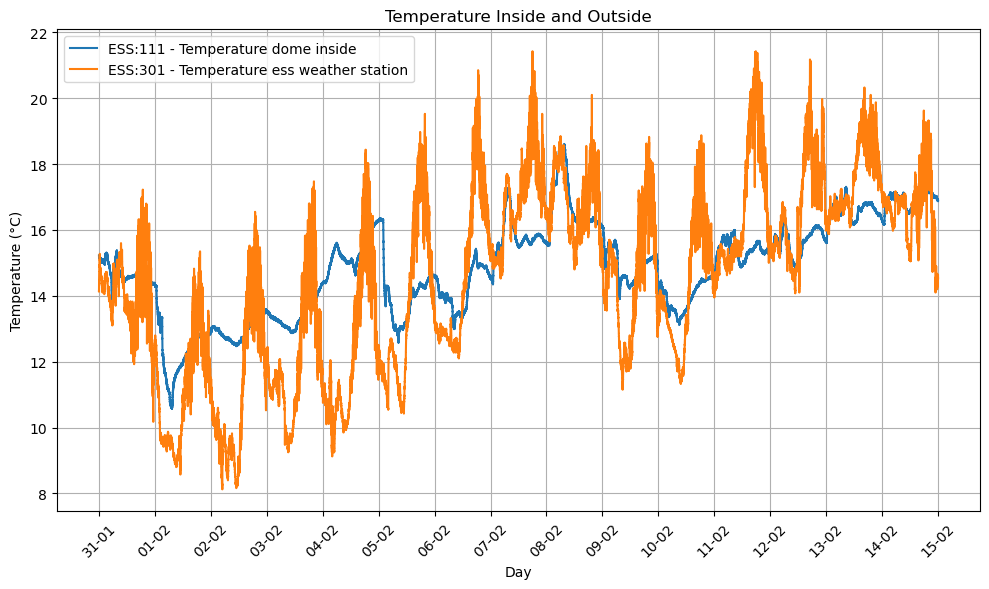

In [25]:
plot_temperature(df_temp_inandout, title="Temperature Inside and Outside")

### Cross with the louver settings

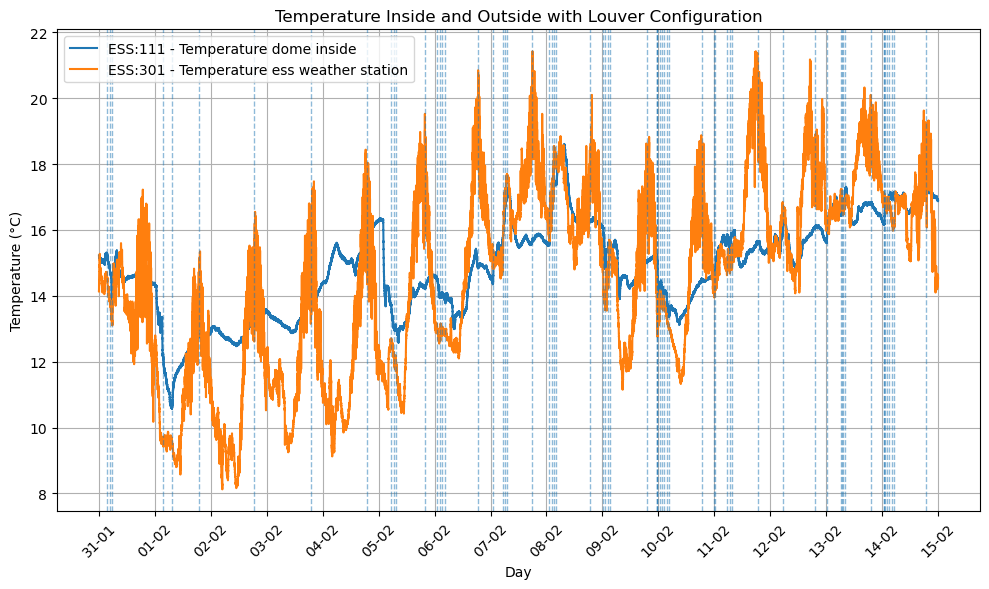

In [26]:
plot_temperature_with_line_louvers(
    df_temp_inandout,
    df_setlouvers,
    "Temperature Inside and Outside with Louver Configuration"
)

In [27]:
# Add in df_setlouvers configuration the end of each configuration
df_setlouvers['time_end'] = df_setlouvers['time_stamp'].shift(-1)
df_temp_inandout['time'] = pd.to_datetime(df_temp_inandout['timestamp'], unit='s')
max_time = df_temp_inandout['time'].max()
df_setlouvers['time_end'] = df_setlouvers['time_end'].fillna(max_time)

In [28]:
# Column positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Function to labels
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]

    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"

    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

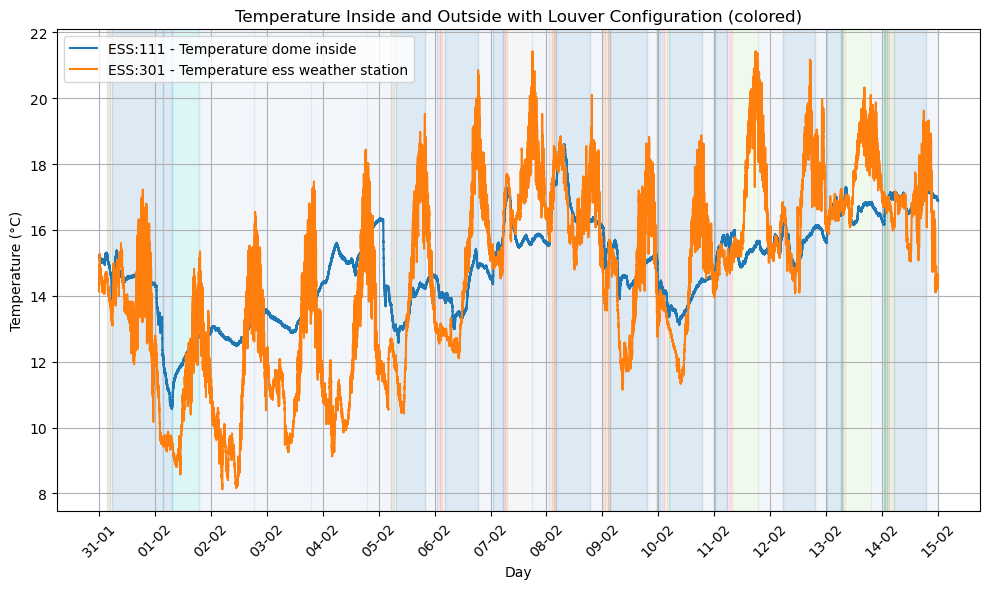

In [29]:
plot_temperature_with_louver_shading(
    df_temp_inandout,
    df_setlouvers,
    "Temperature Inside and Outside with Louver Configuration (colored)"
)

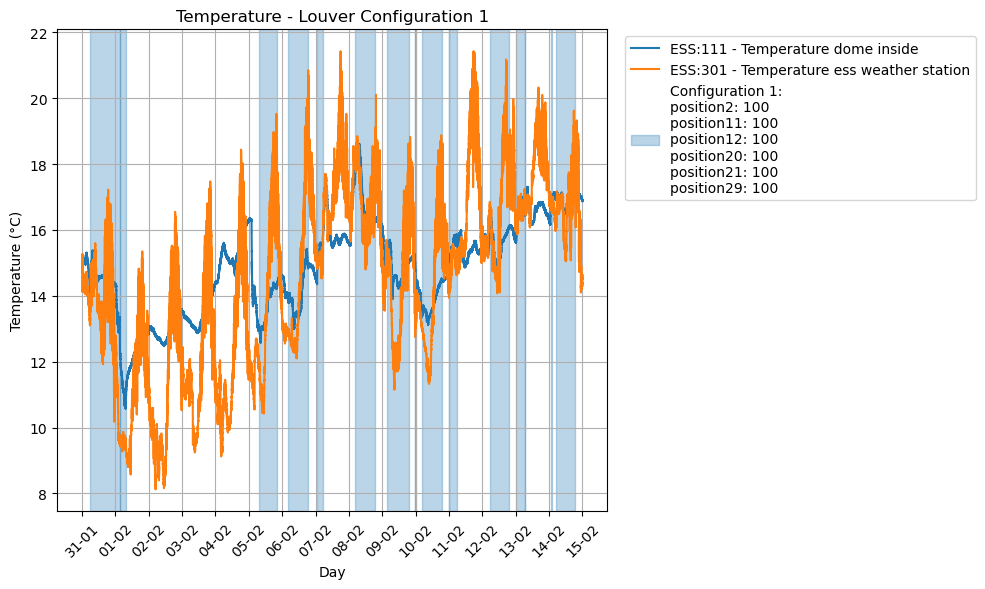

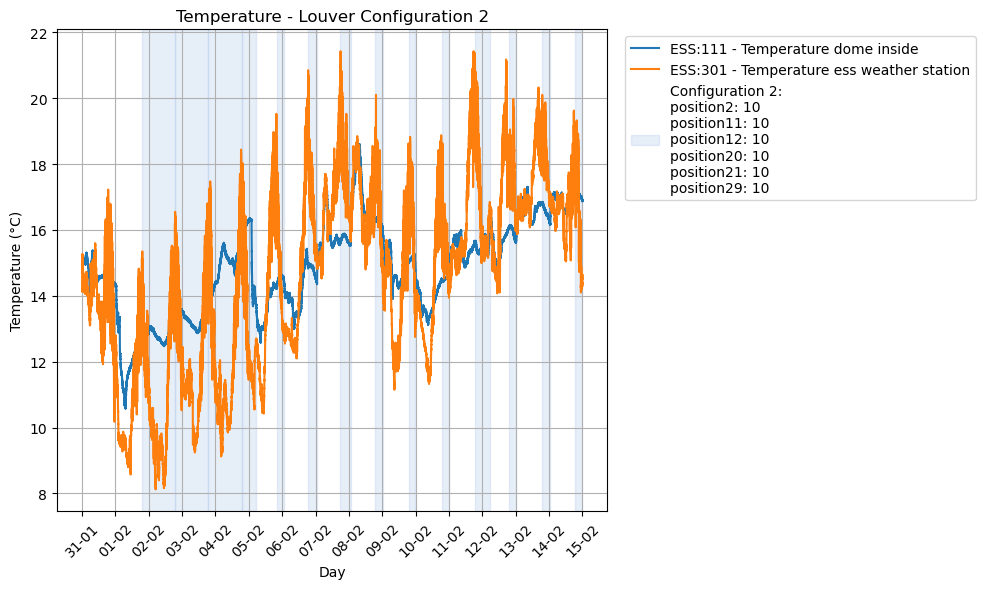

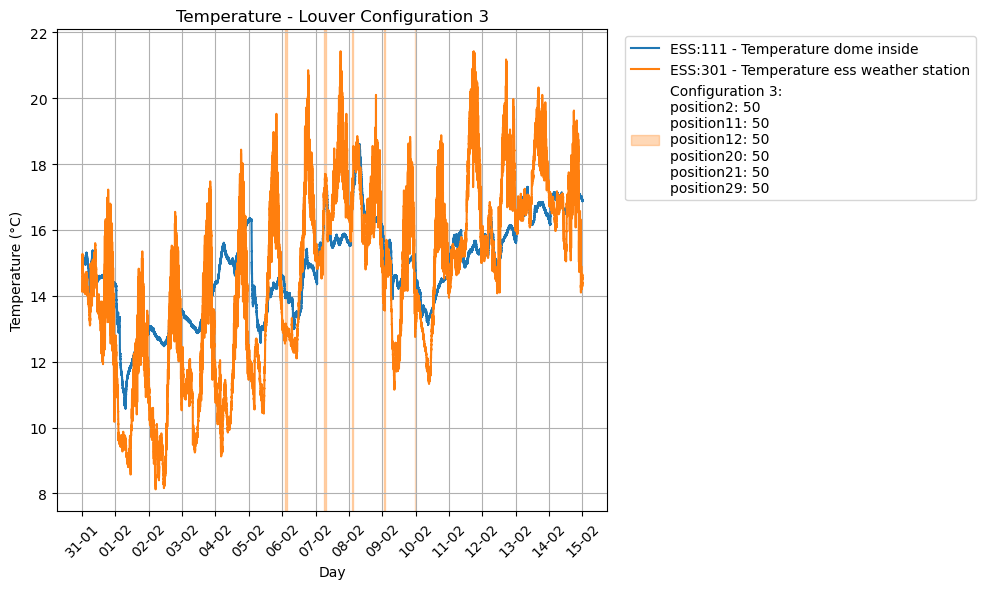

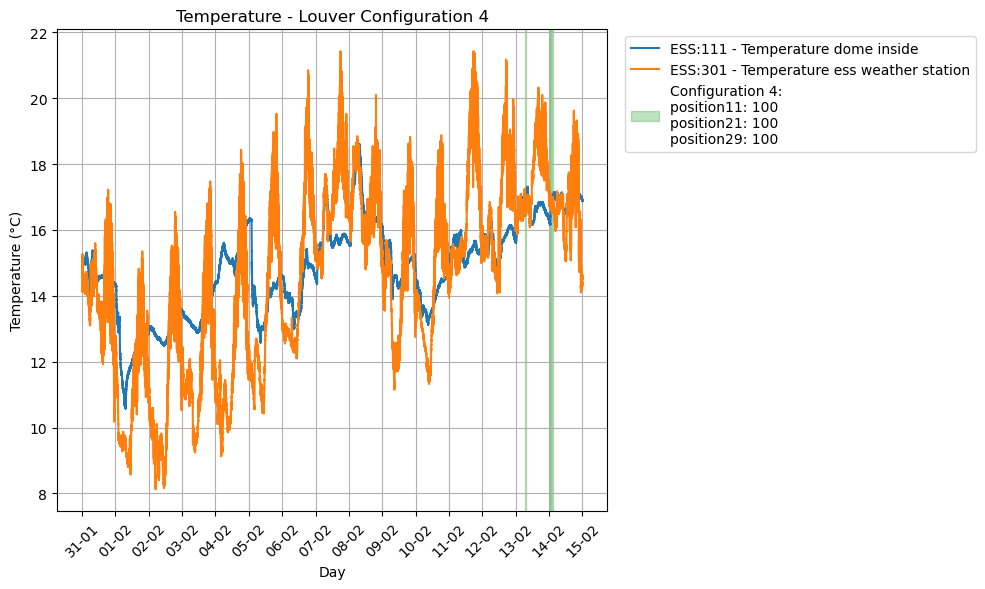

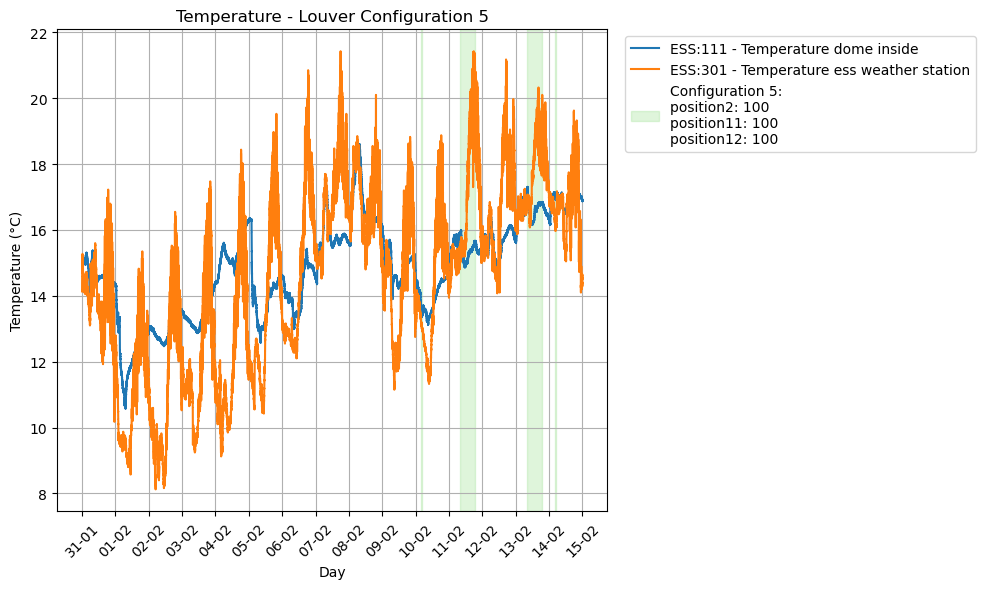

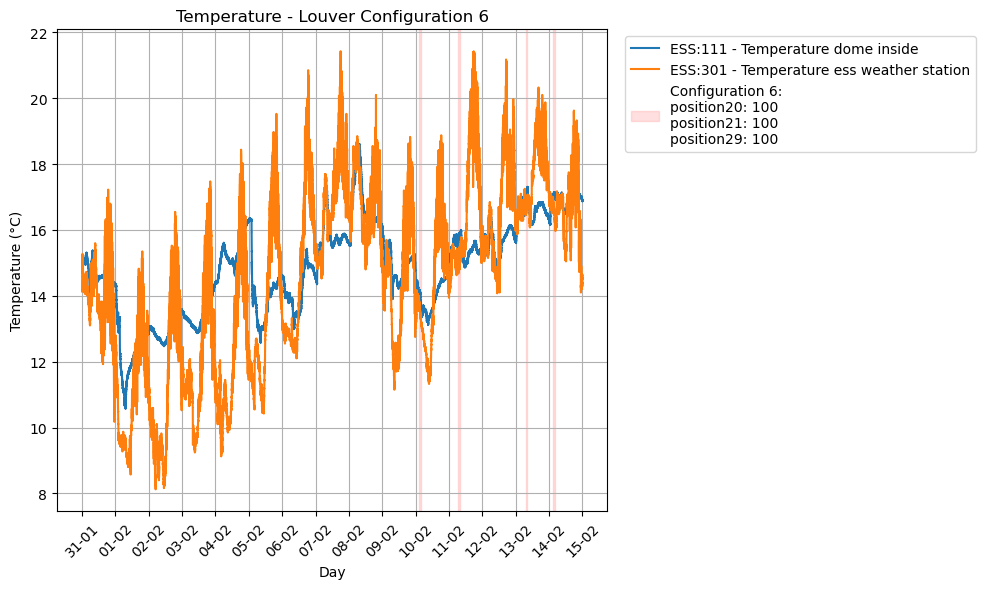

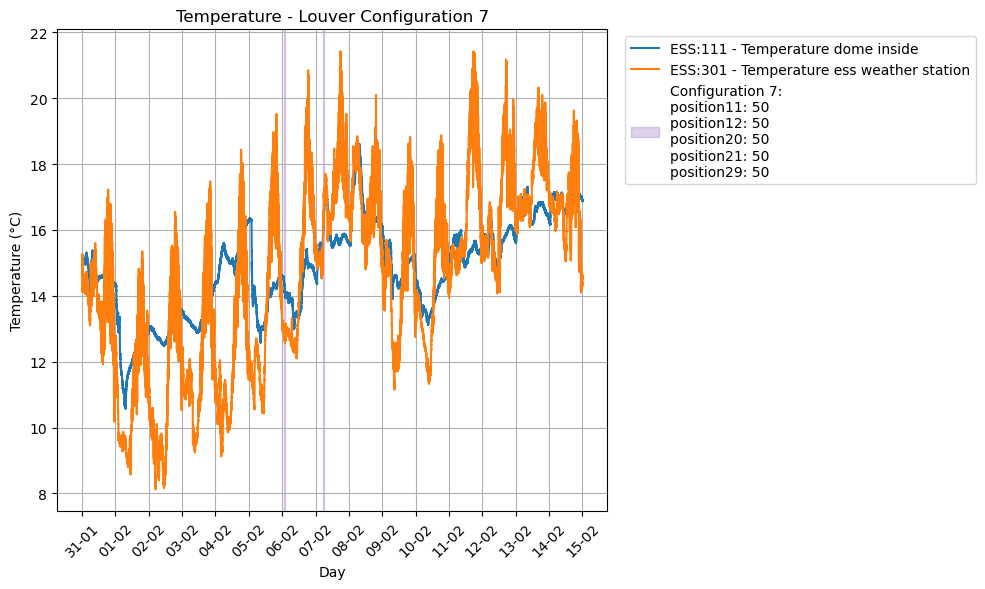

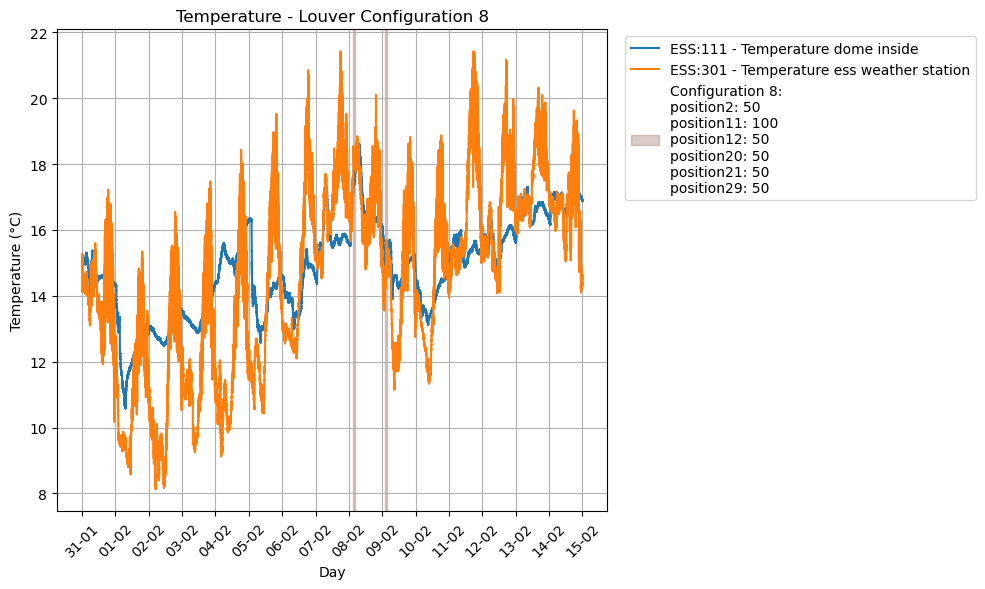

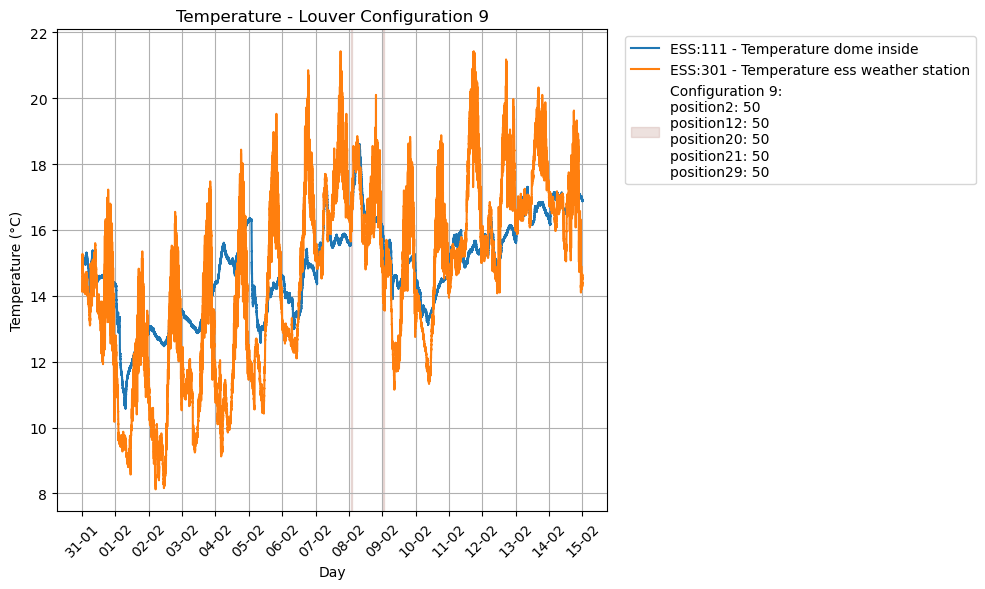

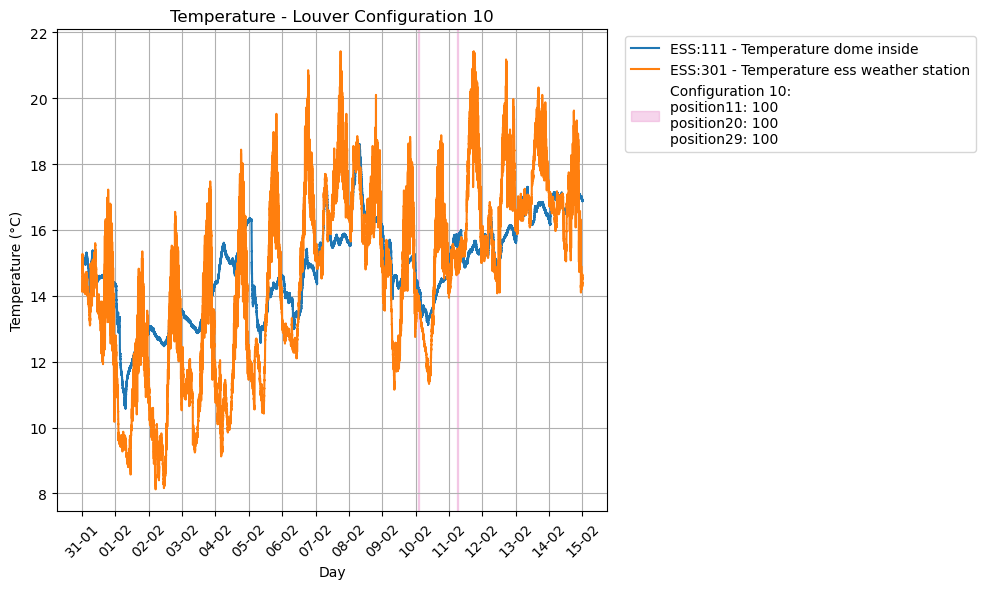

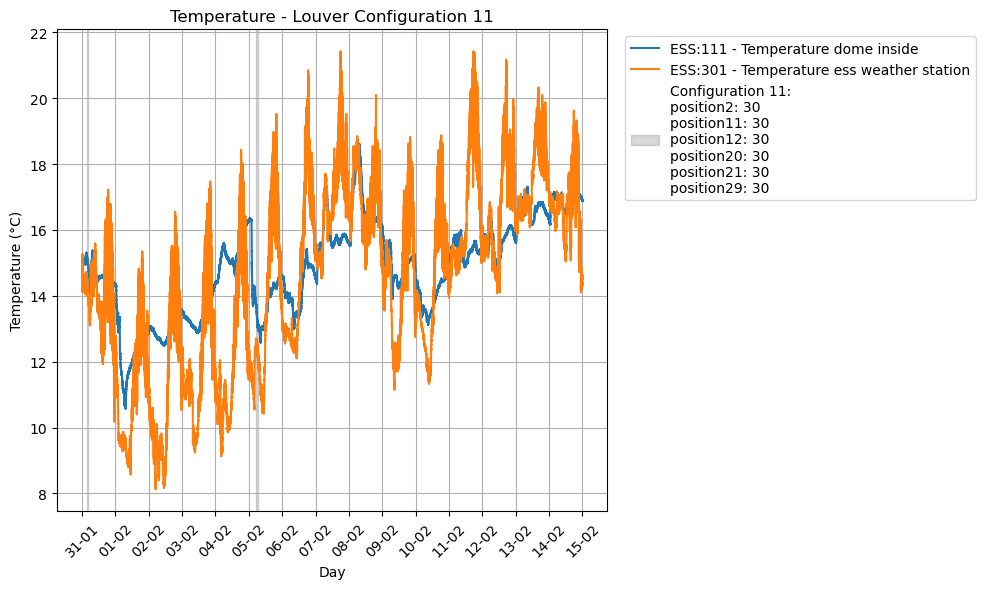

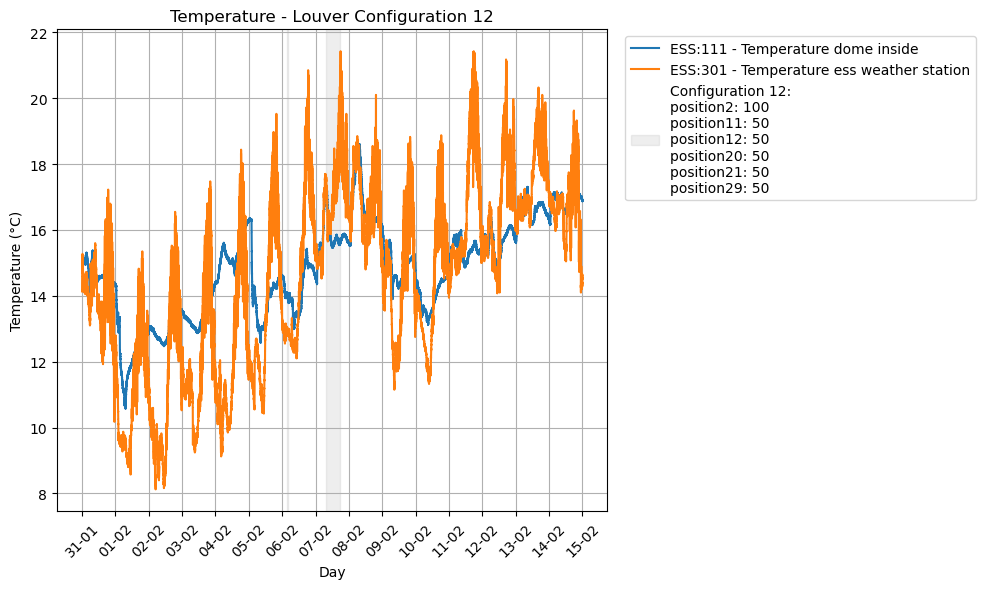

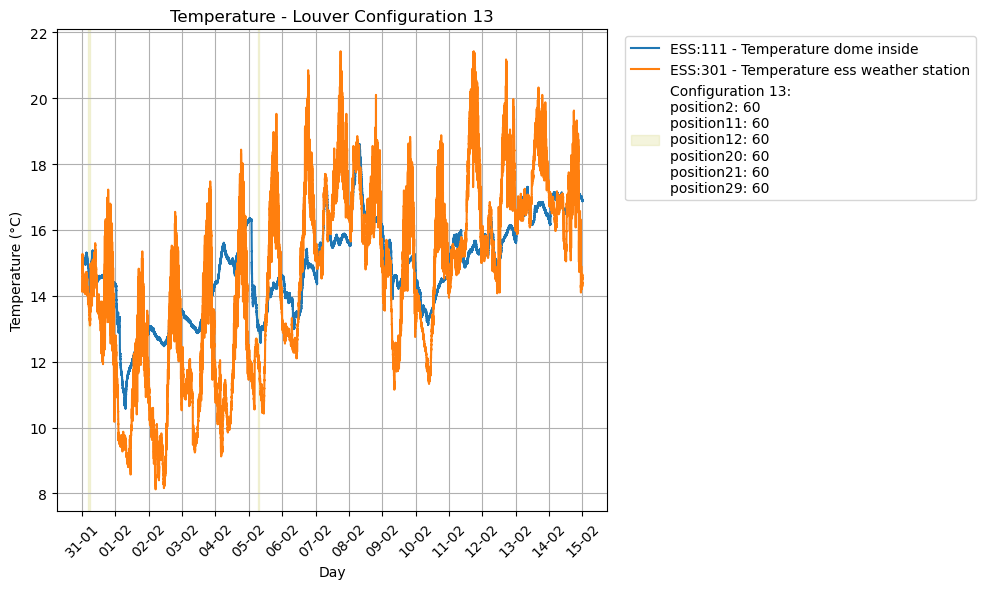

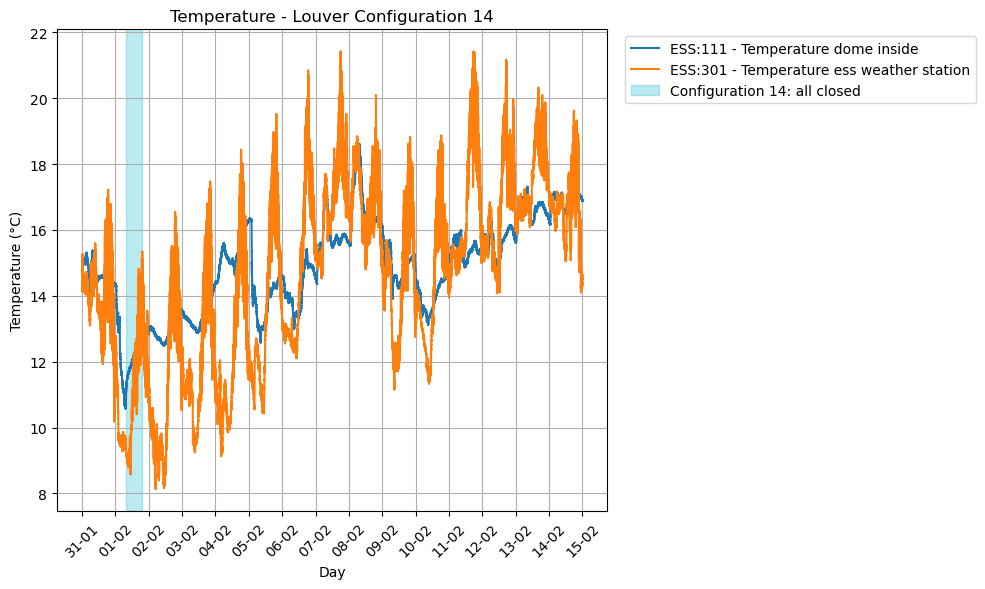

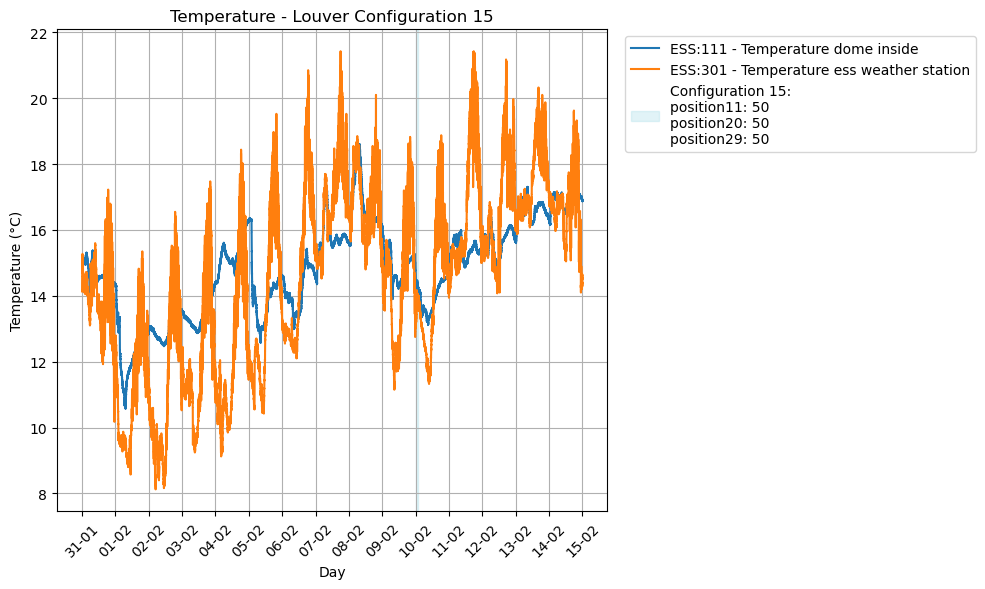

In [30]:
plot_temperature_with_louvers(
    df_temp_inandout, 
    df_setlouvers)

## Make window zoom for configuration beteween 40 and 90 min

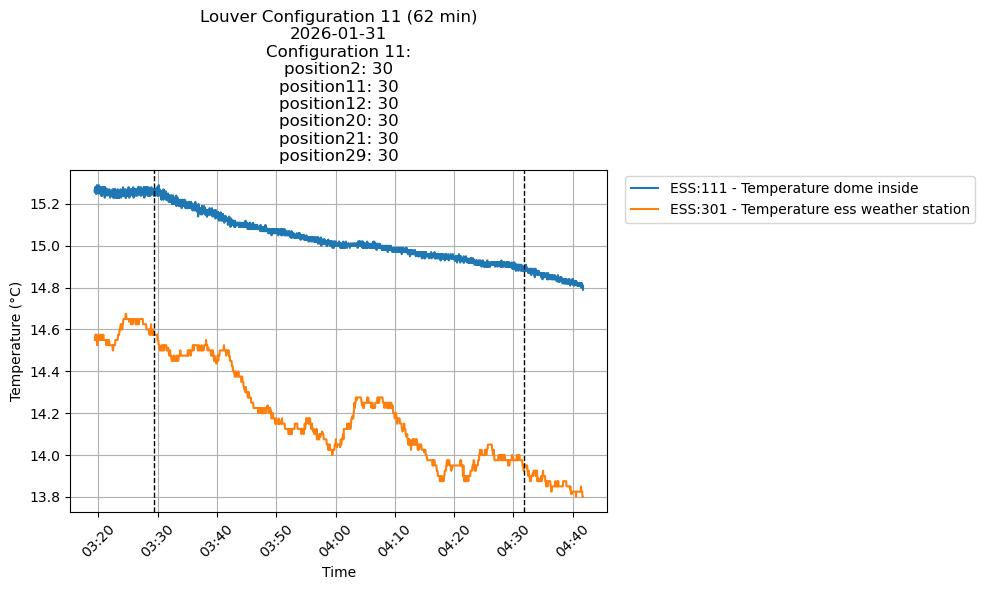

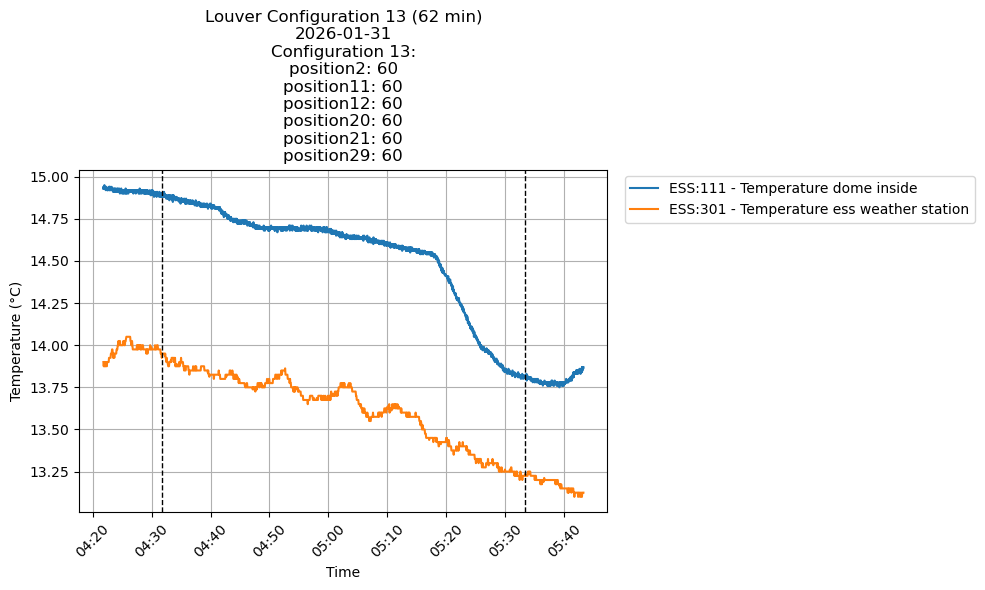

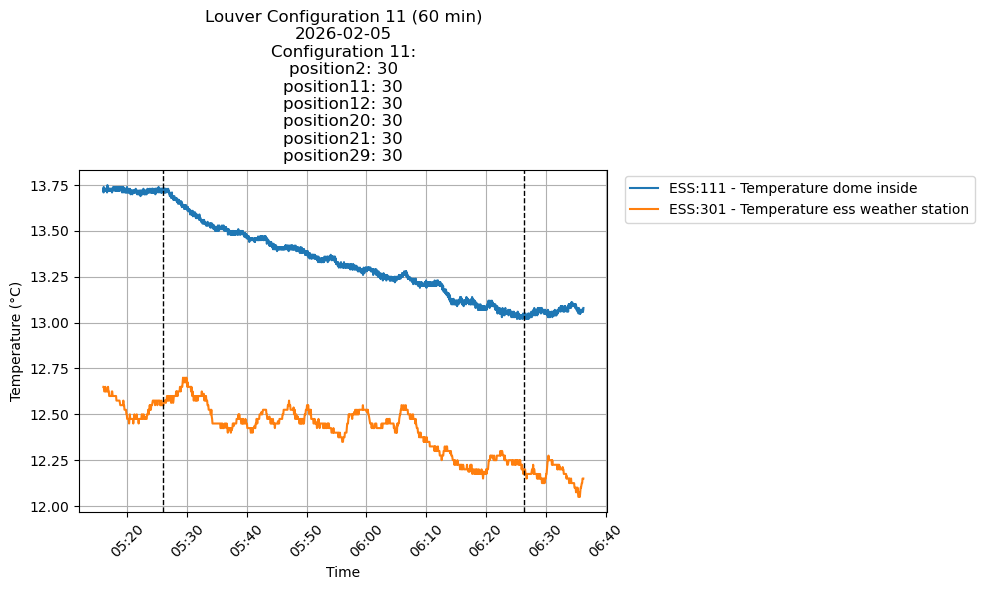

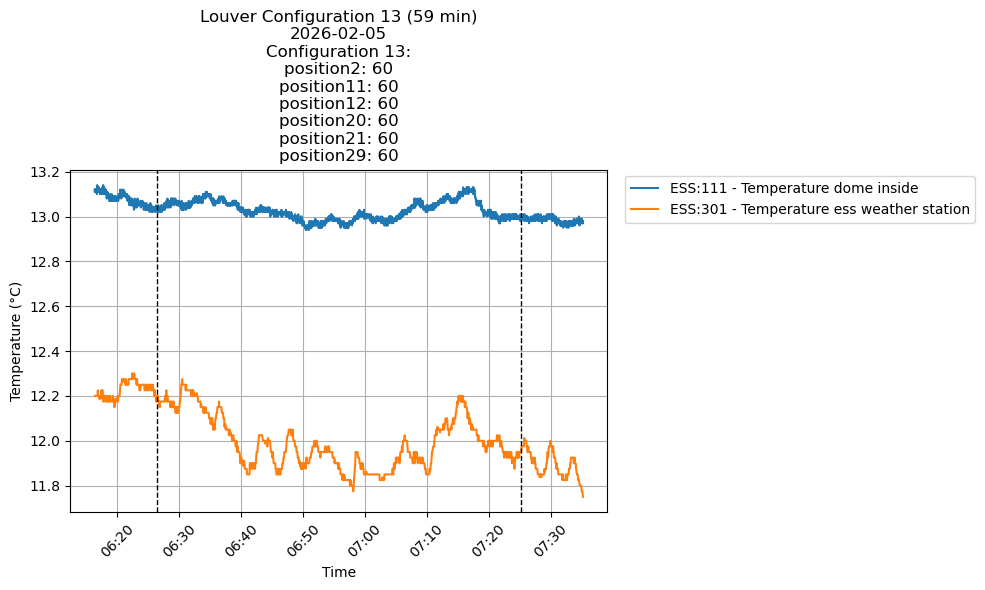

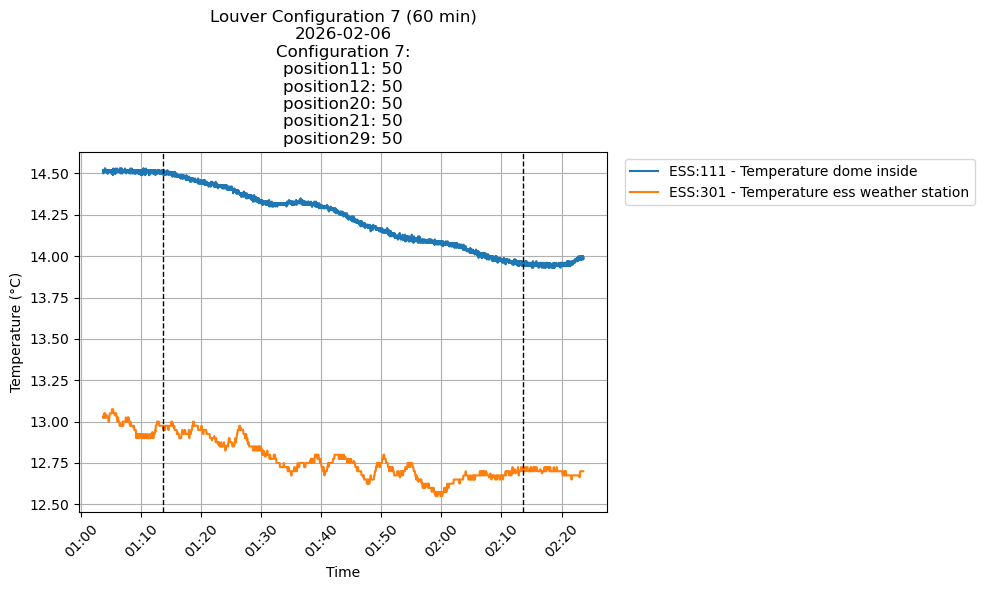

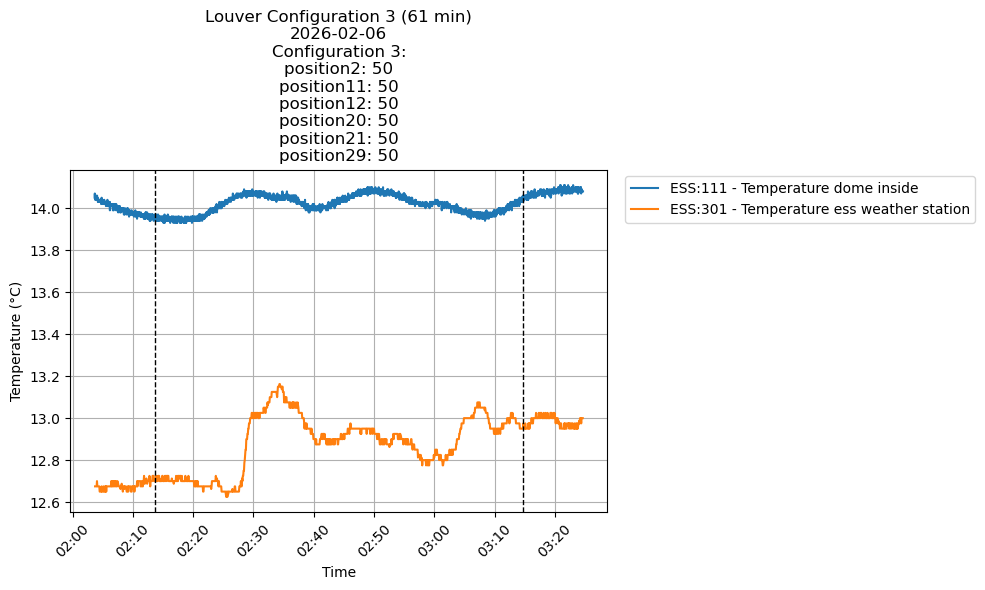

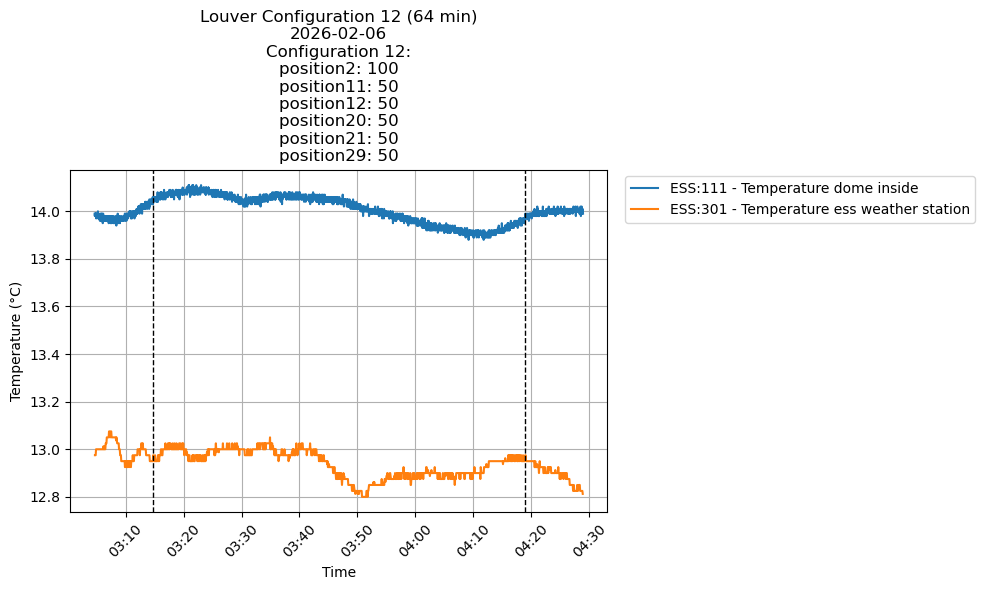

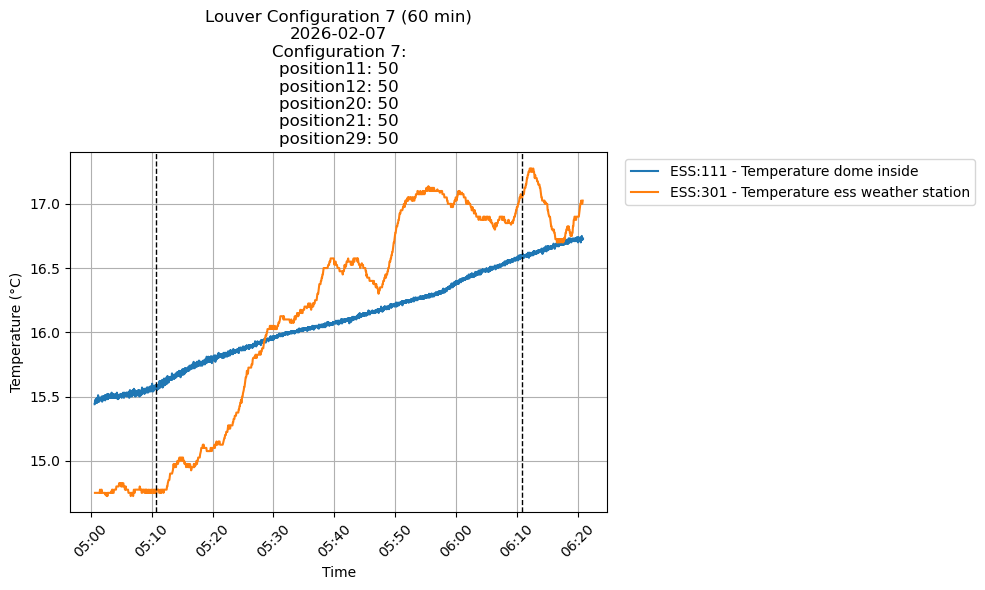

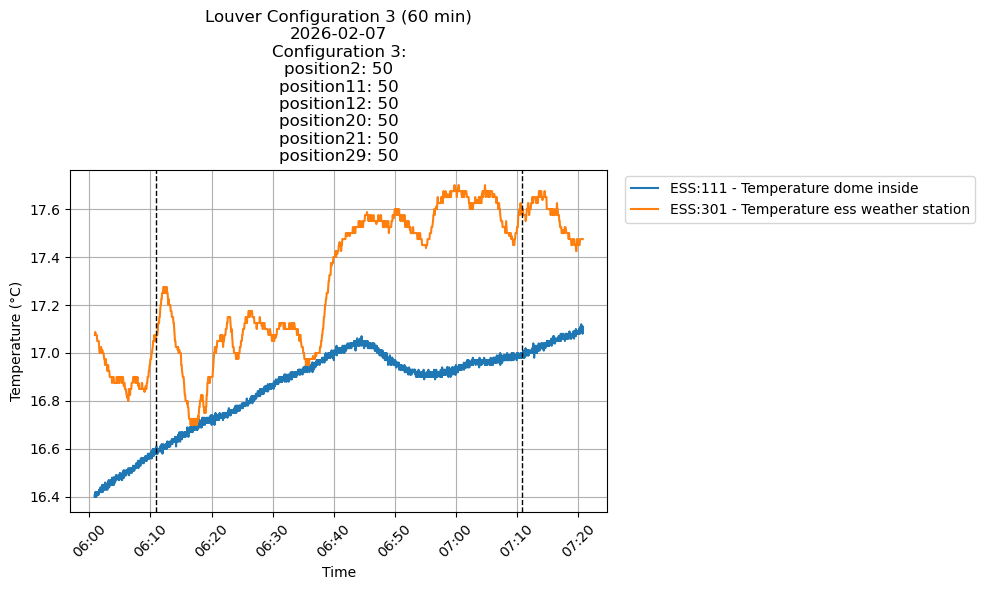

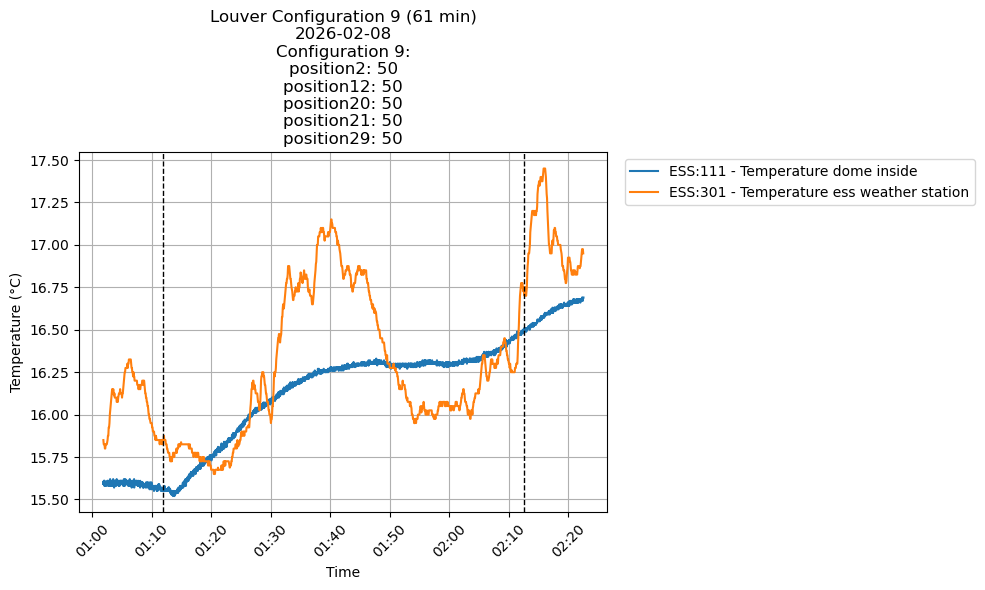

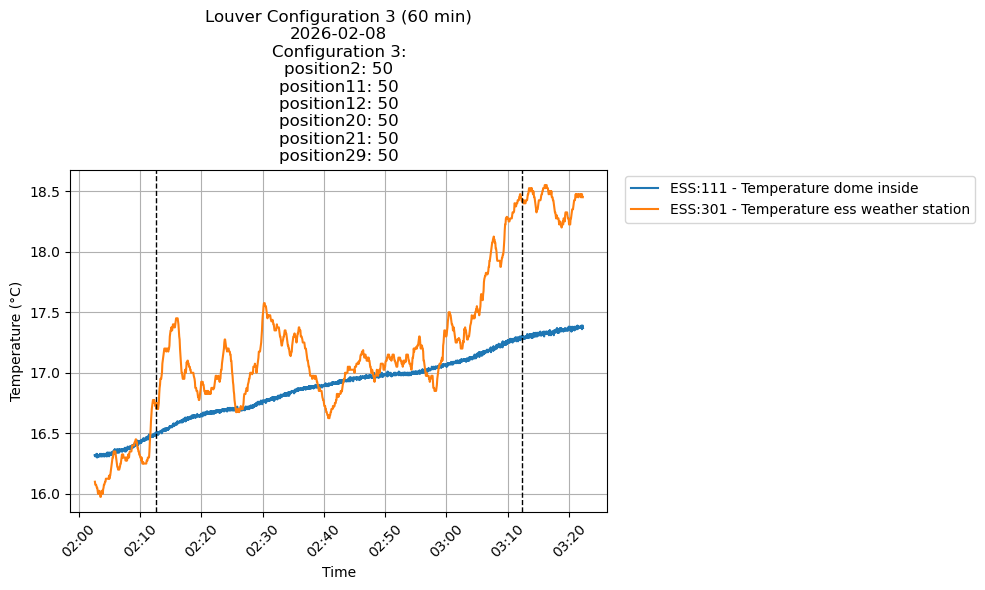

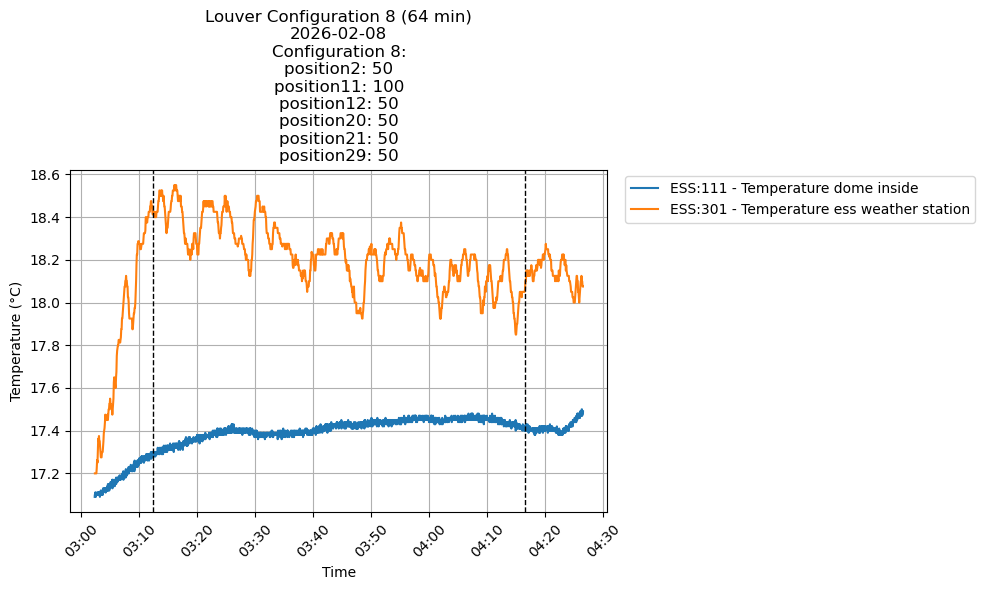

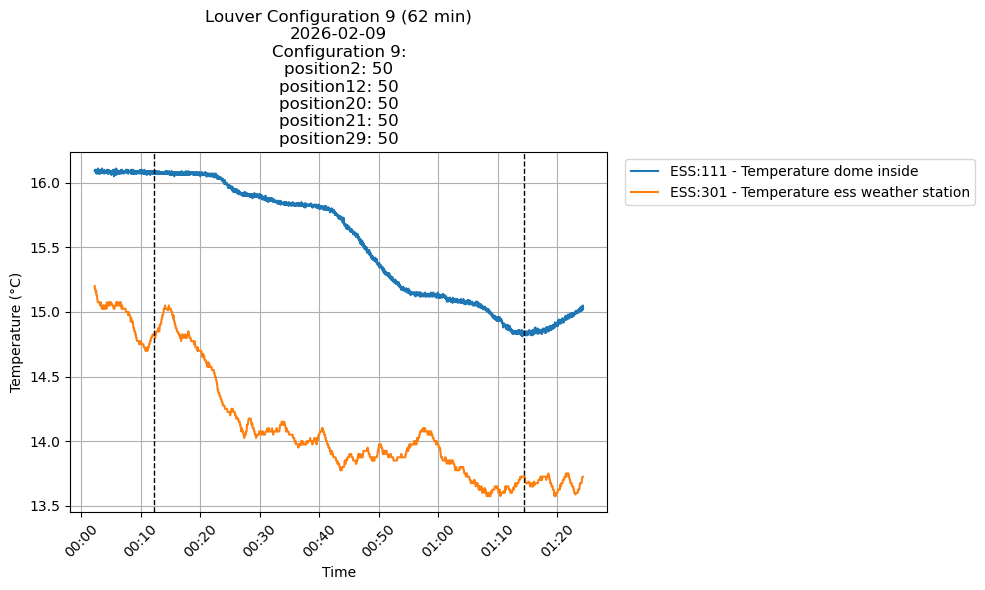

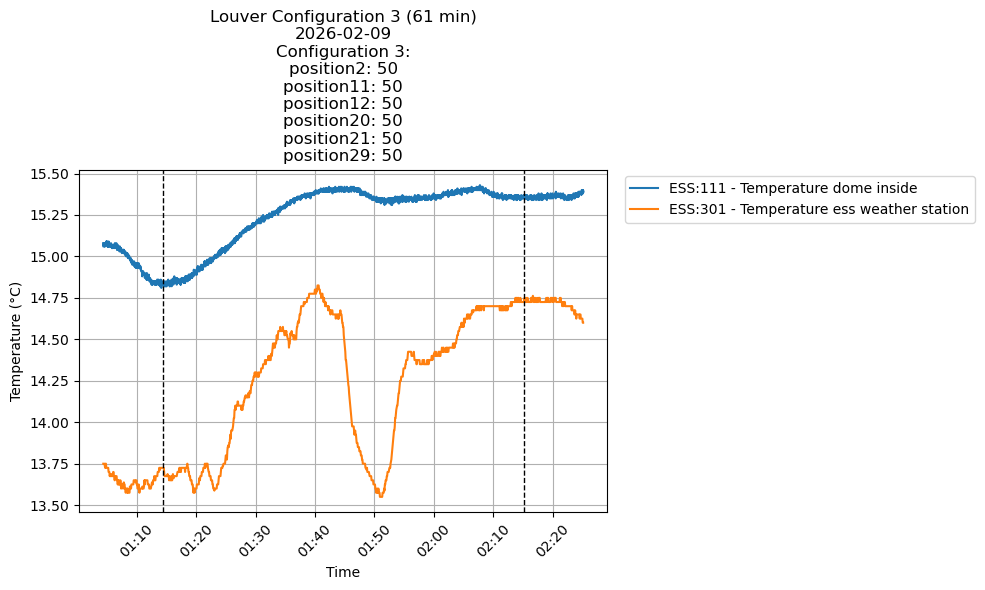

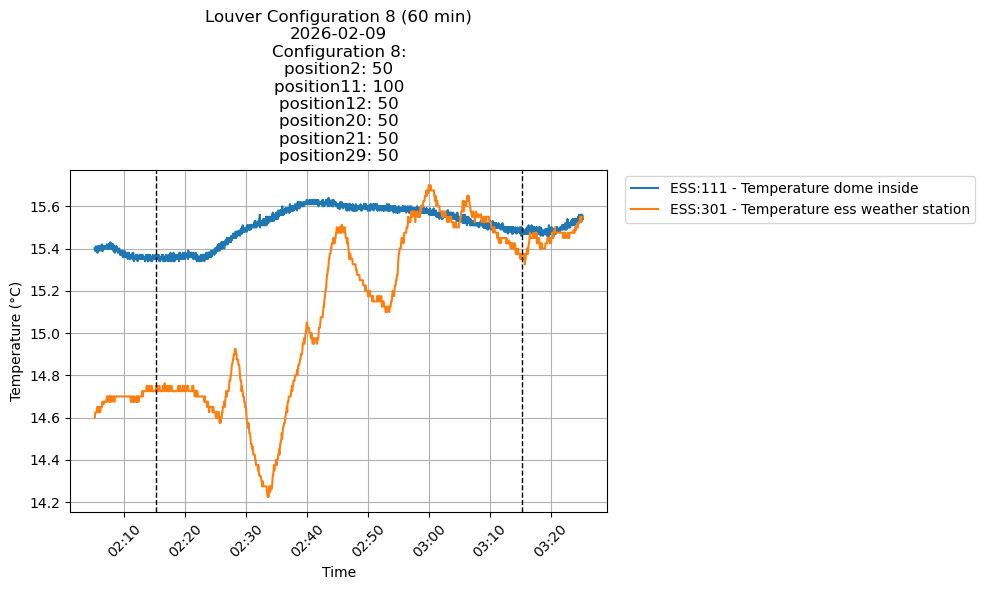

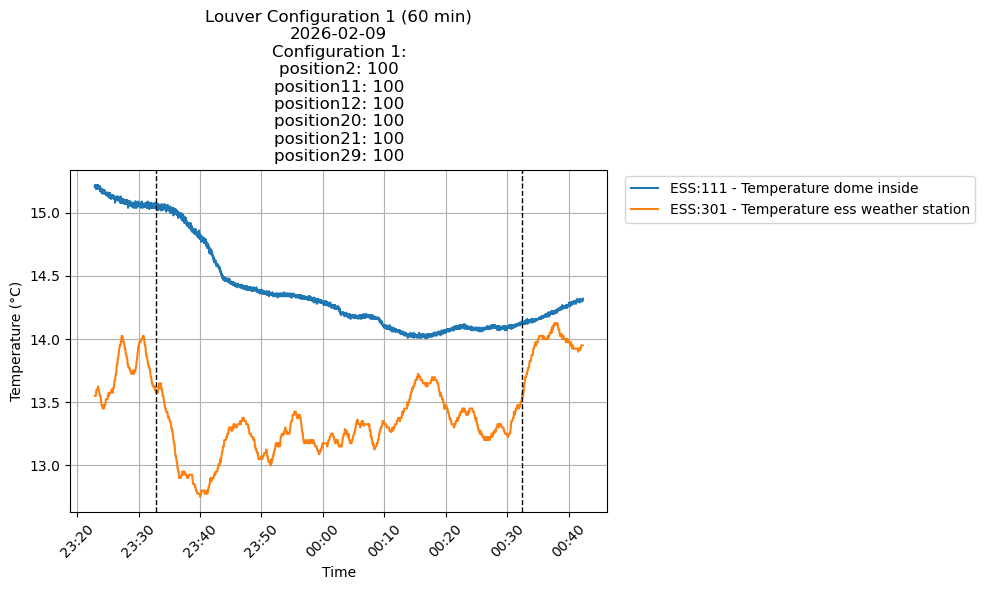

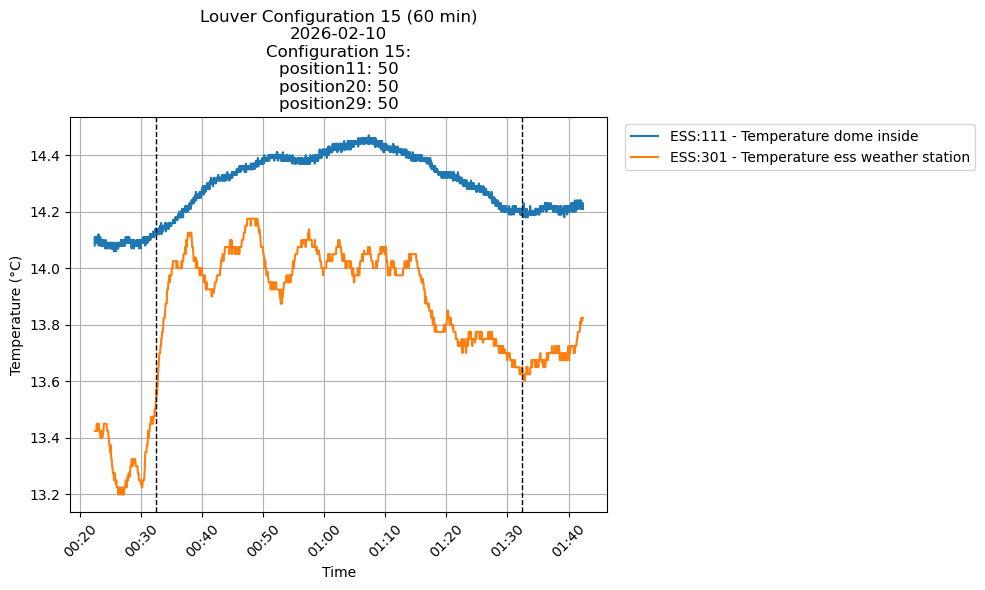

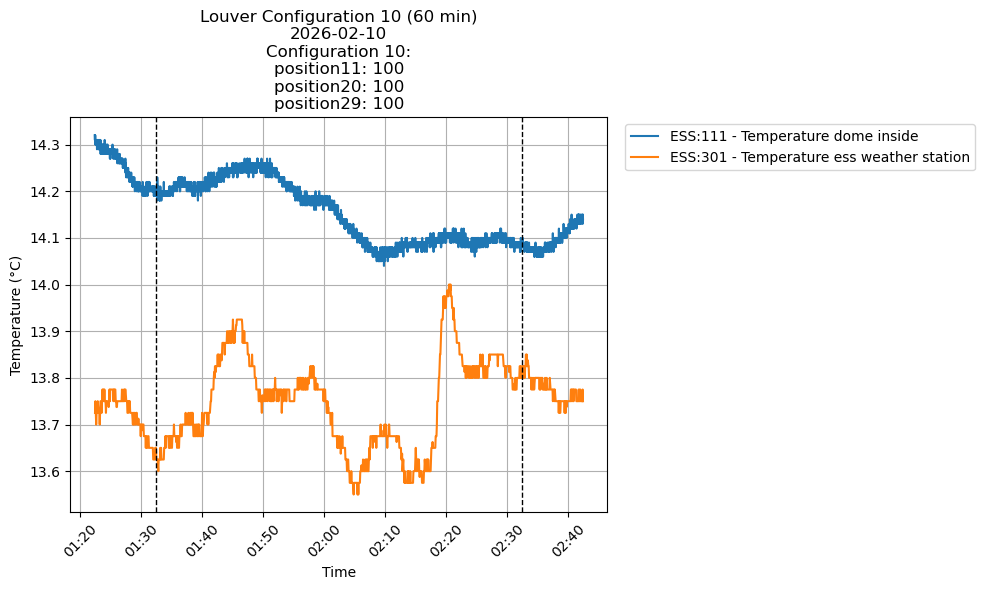

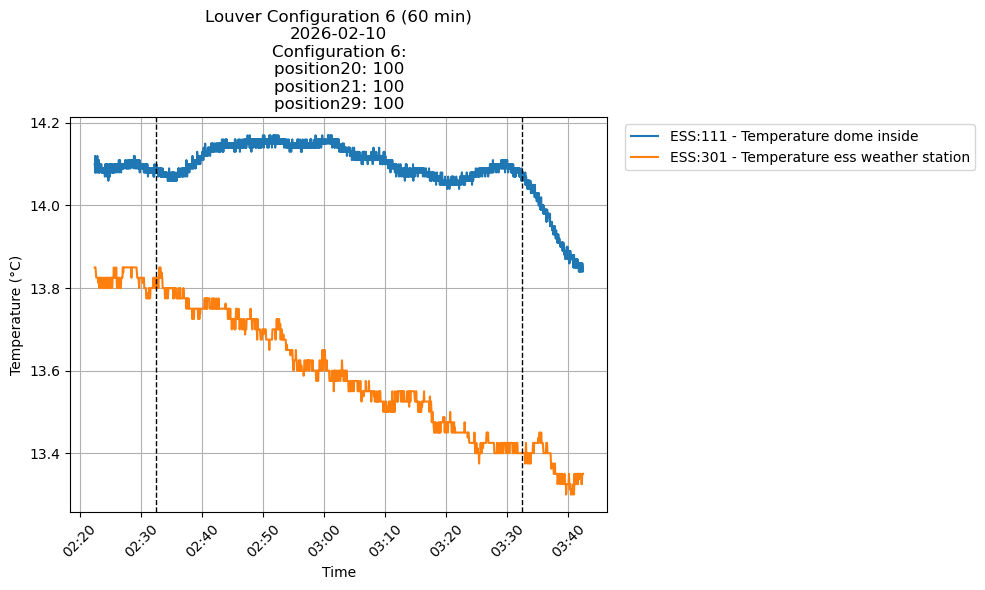

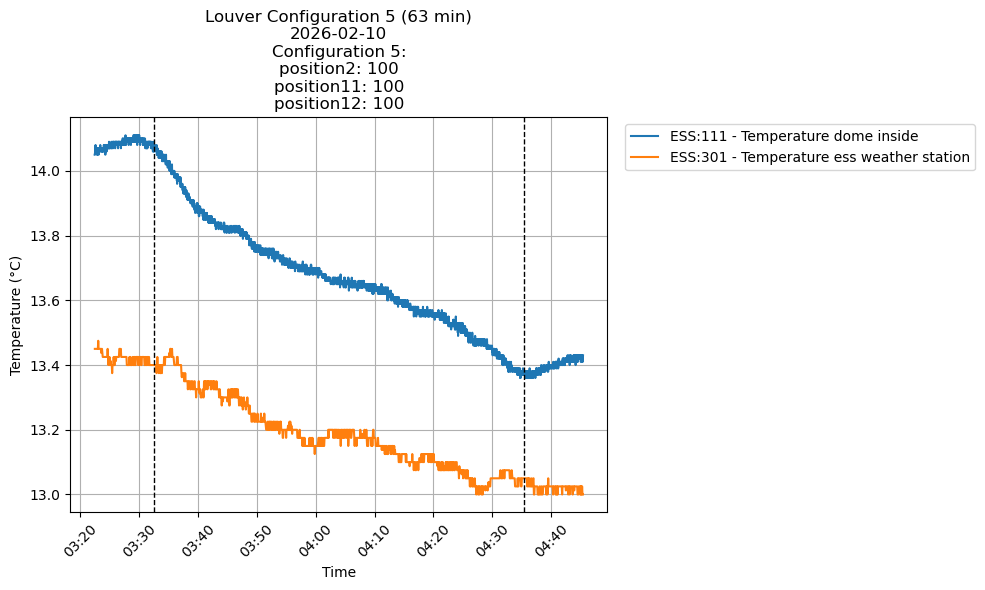

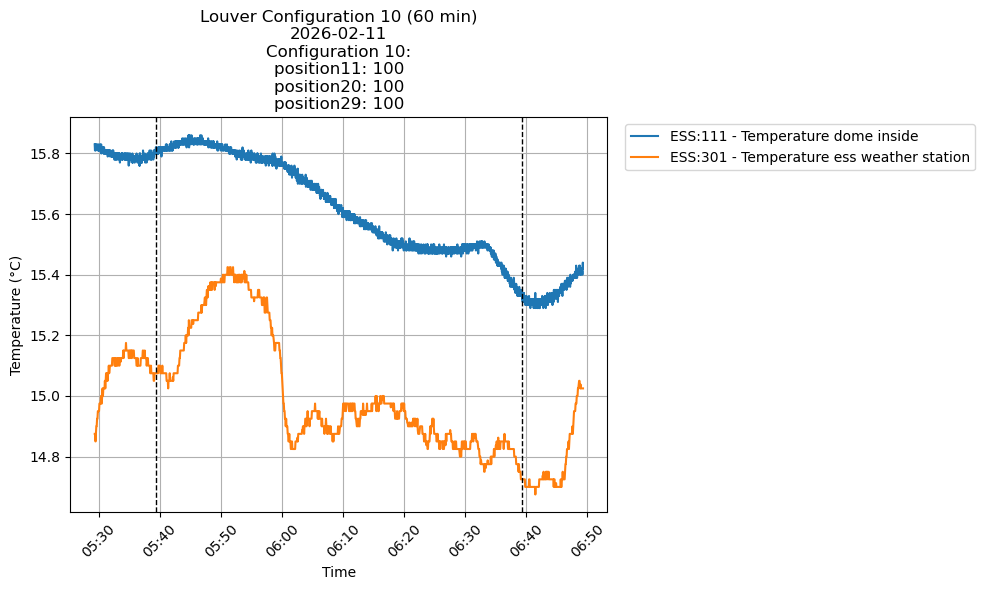

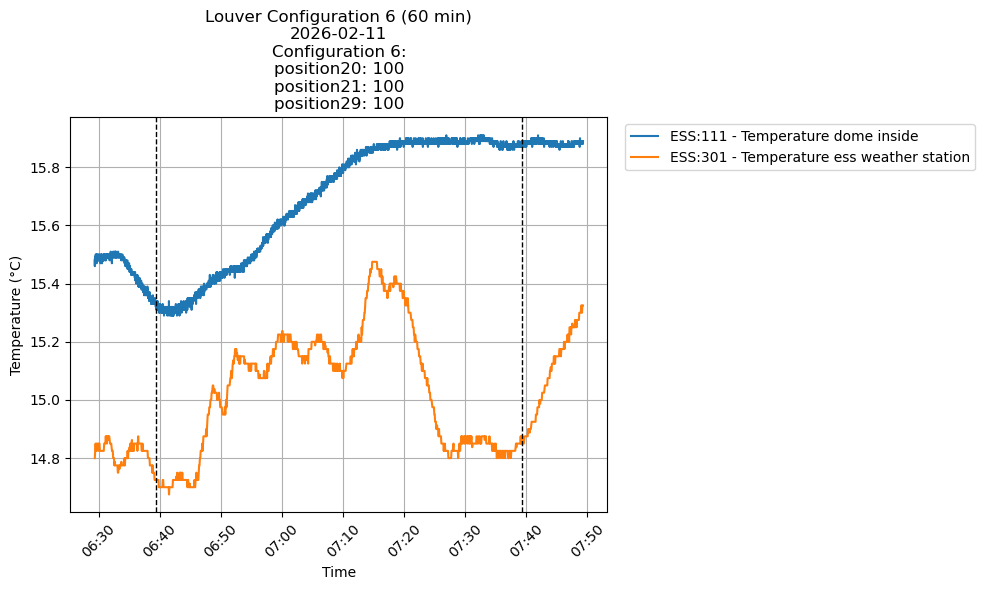

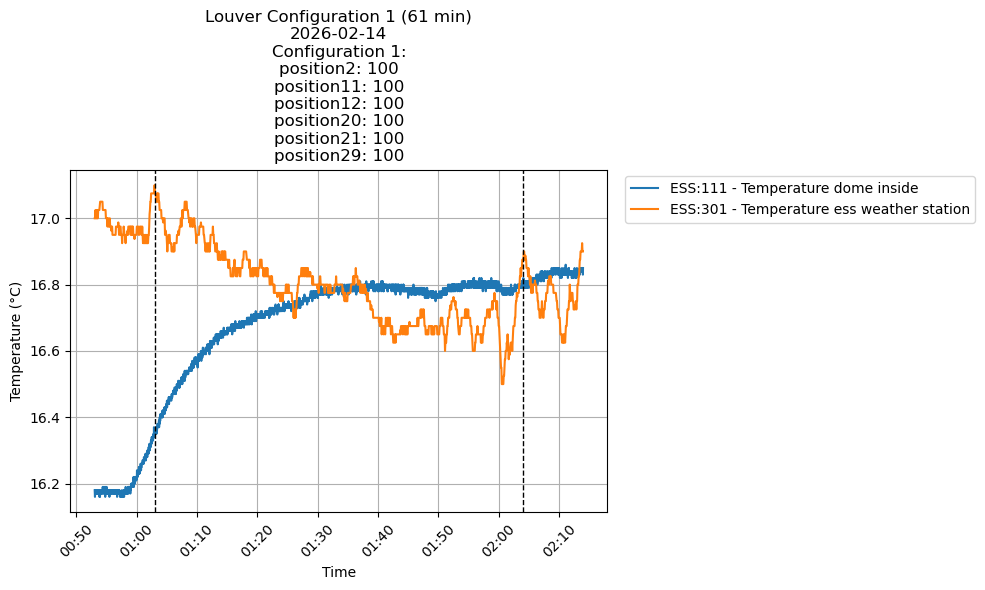

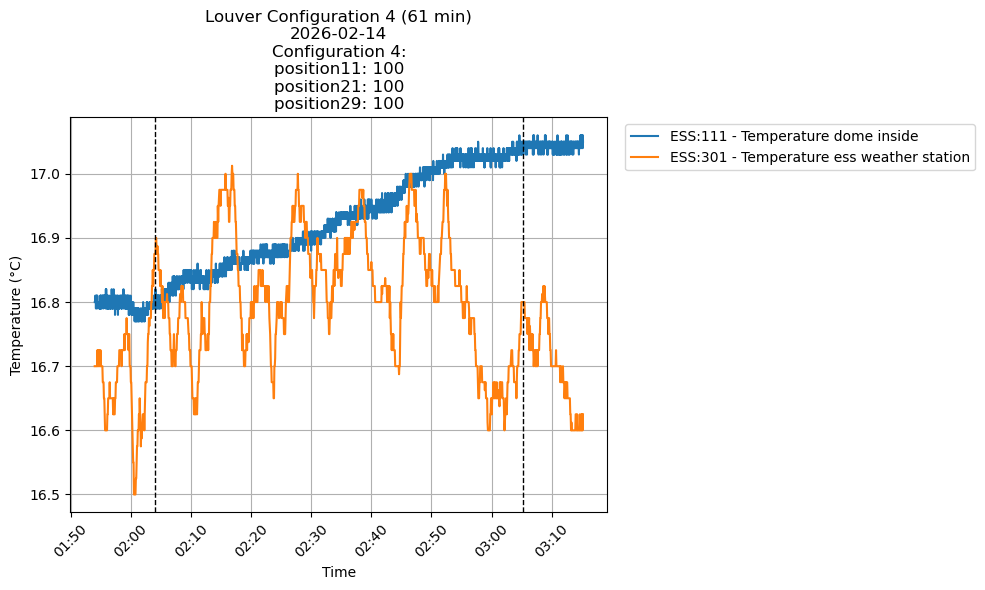

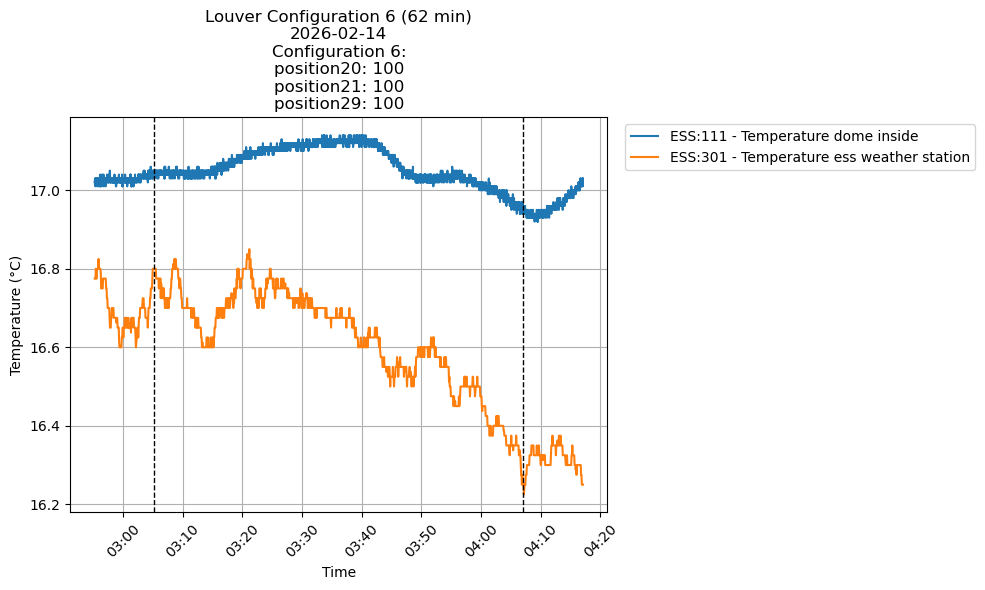

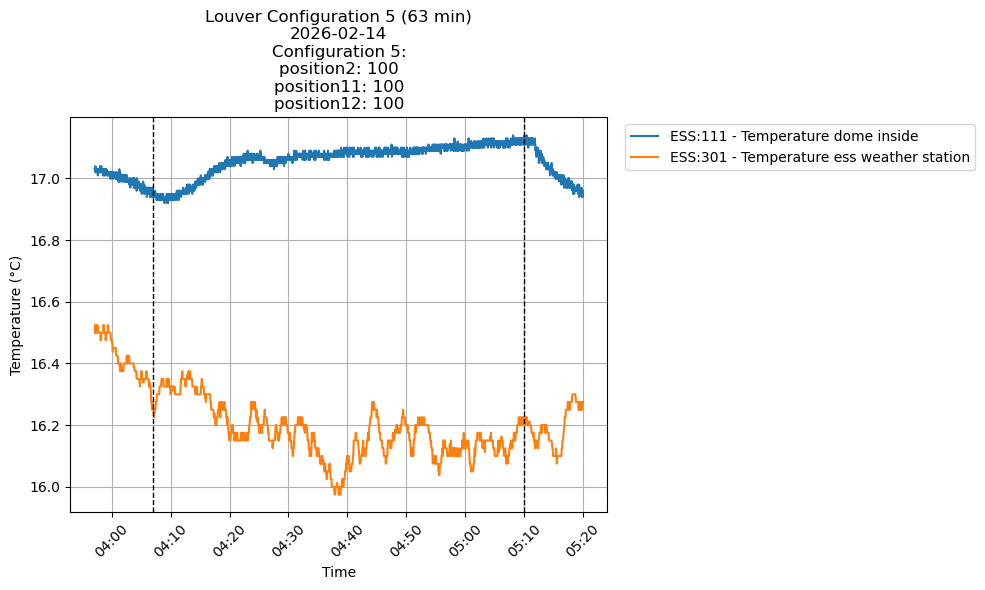

In [31]:
plot_temperature_zoom(df_temp_inandout, df_setlouvers)

Table: basic statistics per configuration (average, variation)

In [32]:
df_temp_inandout['time'] = pd.to_datetime(df_temp_inandout['time'], utc=True).dt.tz_convert(None)
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True).dt.tz_convert(None)
df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True).dt.tz_convert(None)

In [33]:
df_stats = compute_louvers_stats(df_setlouvers, df_temp_inandout)
df_stats

,louvers_conf,conf_label,duration,mean_temp_ESS:301,std_temp_ESS:301,mean_temp_ESS:111,std_temp_ESS:111,mean_delta_T_ESS:111_vs_ESS:301,std_delta_T_ESS:111_vs_ESS:301
0,11,Configuration 11:\nposition2: 30\nposition11: ...,62.390887,14.187468,0.202070,15.035317,0.101098,0.847849,0.115417
1,13,Configuration 13:\nposition2: 60\nposition11: ...,61.528541,13.628876,0.206081,14.544708,0.306372,0.915832,0.132291
2,11,Configuration 11:\nposition2: 30\nposition11: ...,60.338251,12.423527,0.125010,13.330742,0.182709,0.907215,0.099173
3,13,Configuration 13:\nposition2: 60\nposition11: ...,58.953490,11.993926,0.115016,13.026345,0.039954,1.032419,0.090891
4,7,Configuration 7:\nposition11: 50\nposition12: ...,59.974735,12.758216,0.109481,14.226217,0.167388,1.468002,0.093273
5,3,Configuration 3:\nposition2: 50\nposition11: 5...,61.003808,12.883395,0.133465,14.018353,0.042042,1.134959,0.122403
6,12,Configuration 12:\nposition2: 100\nposition11:...,64.256685,12.939646,0.056624,14.009354,0.062088,1.069708,0.056031
7,7,Configuration 7:\nposition11: 50\nposition12: ...,60.236978,16.226086,0.762781,16.097099,0.272666,-0.128987,0.520104
8,3,Configuration 3:\nposition2: 50\nposition11: 5...,59.951473,17.314172,0.284476,16.883600,0.124859,-0.430572,0.215908
9,9,Configuration 9:\nposition2: 50\nposition12: 5...,60.728296,16.265363,0.415582,16.143084,0.263094,-0.122279,0.328856


In [34]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [35]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

,louvers_conf,conf_label,duration,mean_temp_ESS:301,std_temp_ESS:301,mean_temp_ESS:111,std_temp_ESS:111,mean_delta_T_ESS:111_vs_ESS:301,std_delta_T_ESS:111_vs_ESS:301
15,1,Configuration 1:\nposition2: 100\nposition11: ...,59.520045,13.270940,0.207632,14.323975,0.301578,1.053035,0.442791
22,1,Configuration 1:\nposition2: 100\nposition11: ...,60.937592,16.787295,0.114606,16.719110,0.109452,-0.068185,0.215142


In [36]:
# plot_mean_temp_per_louver(df_stats, df_setlouvers)

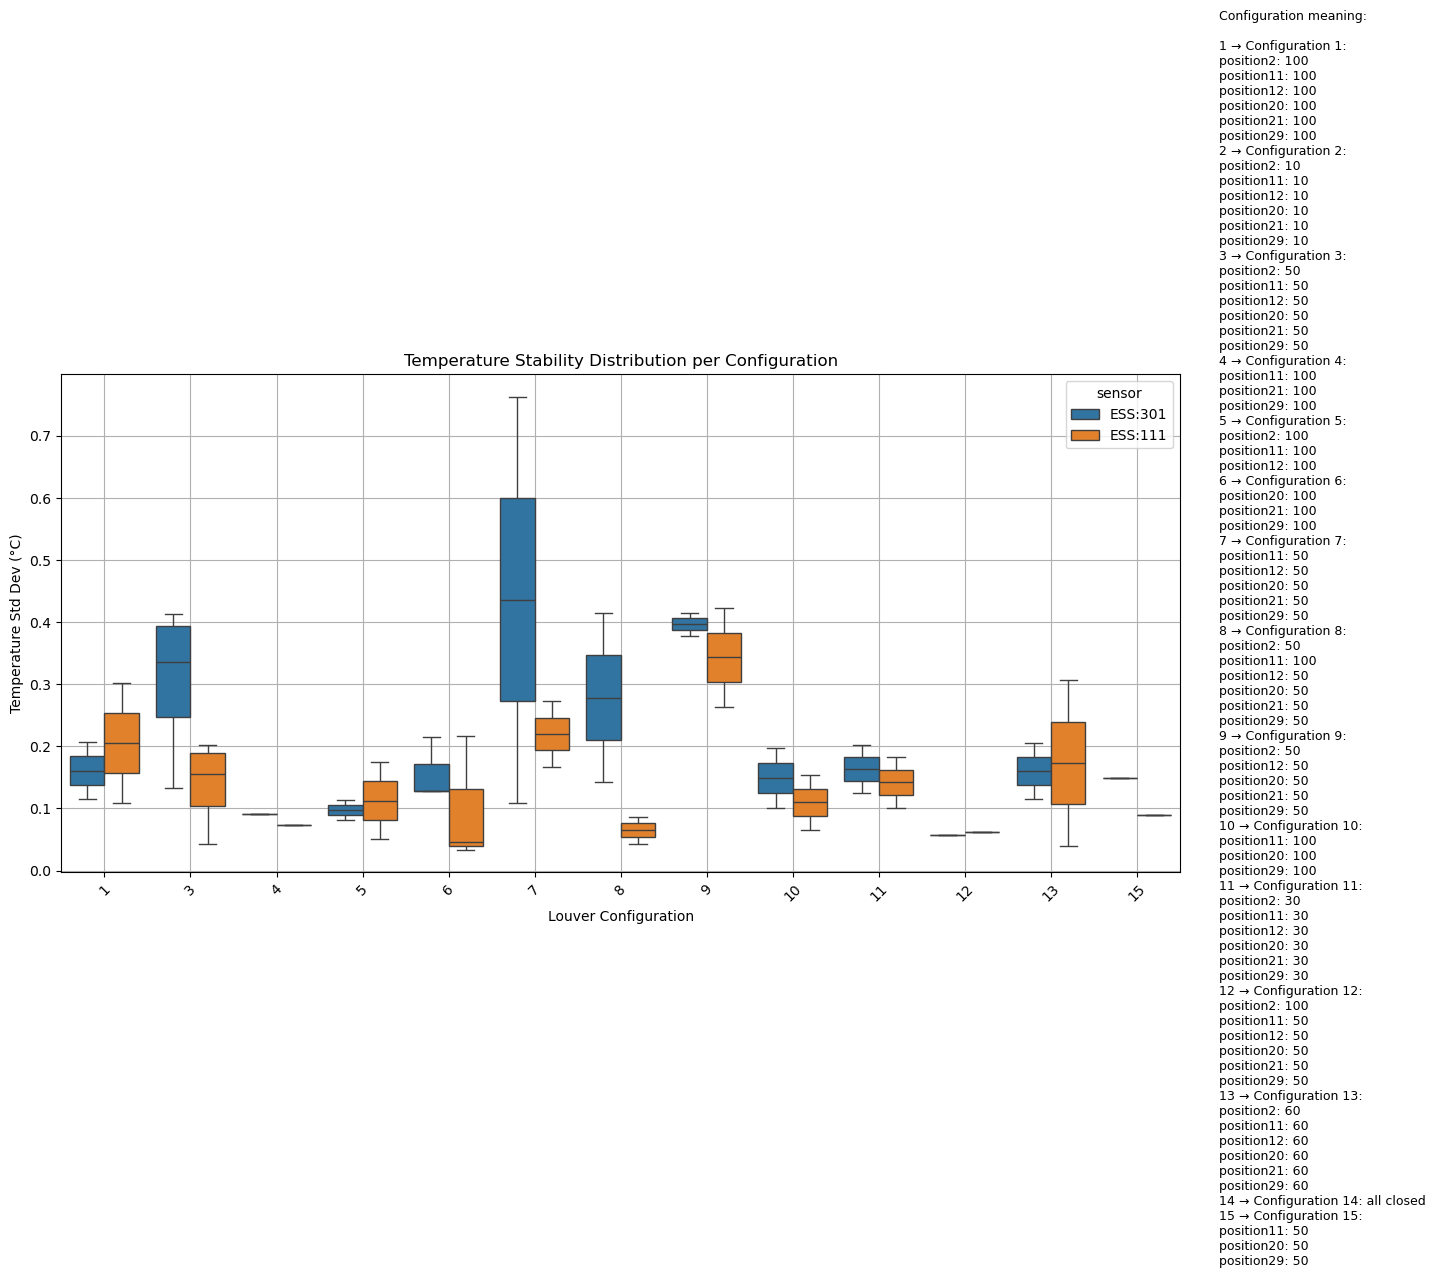

In [37]:
plot_temp_distribution_per_louver(df_stats, df_setlouvers)

nan


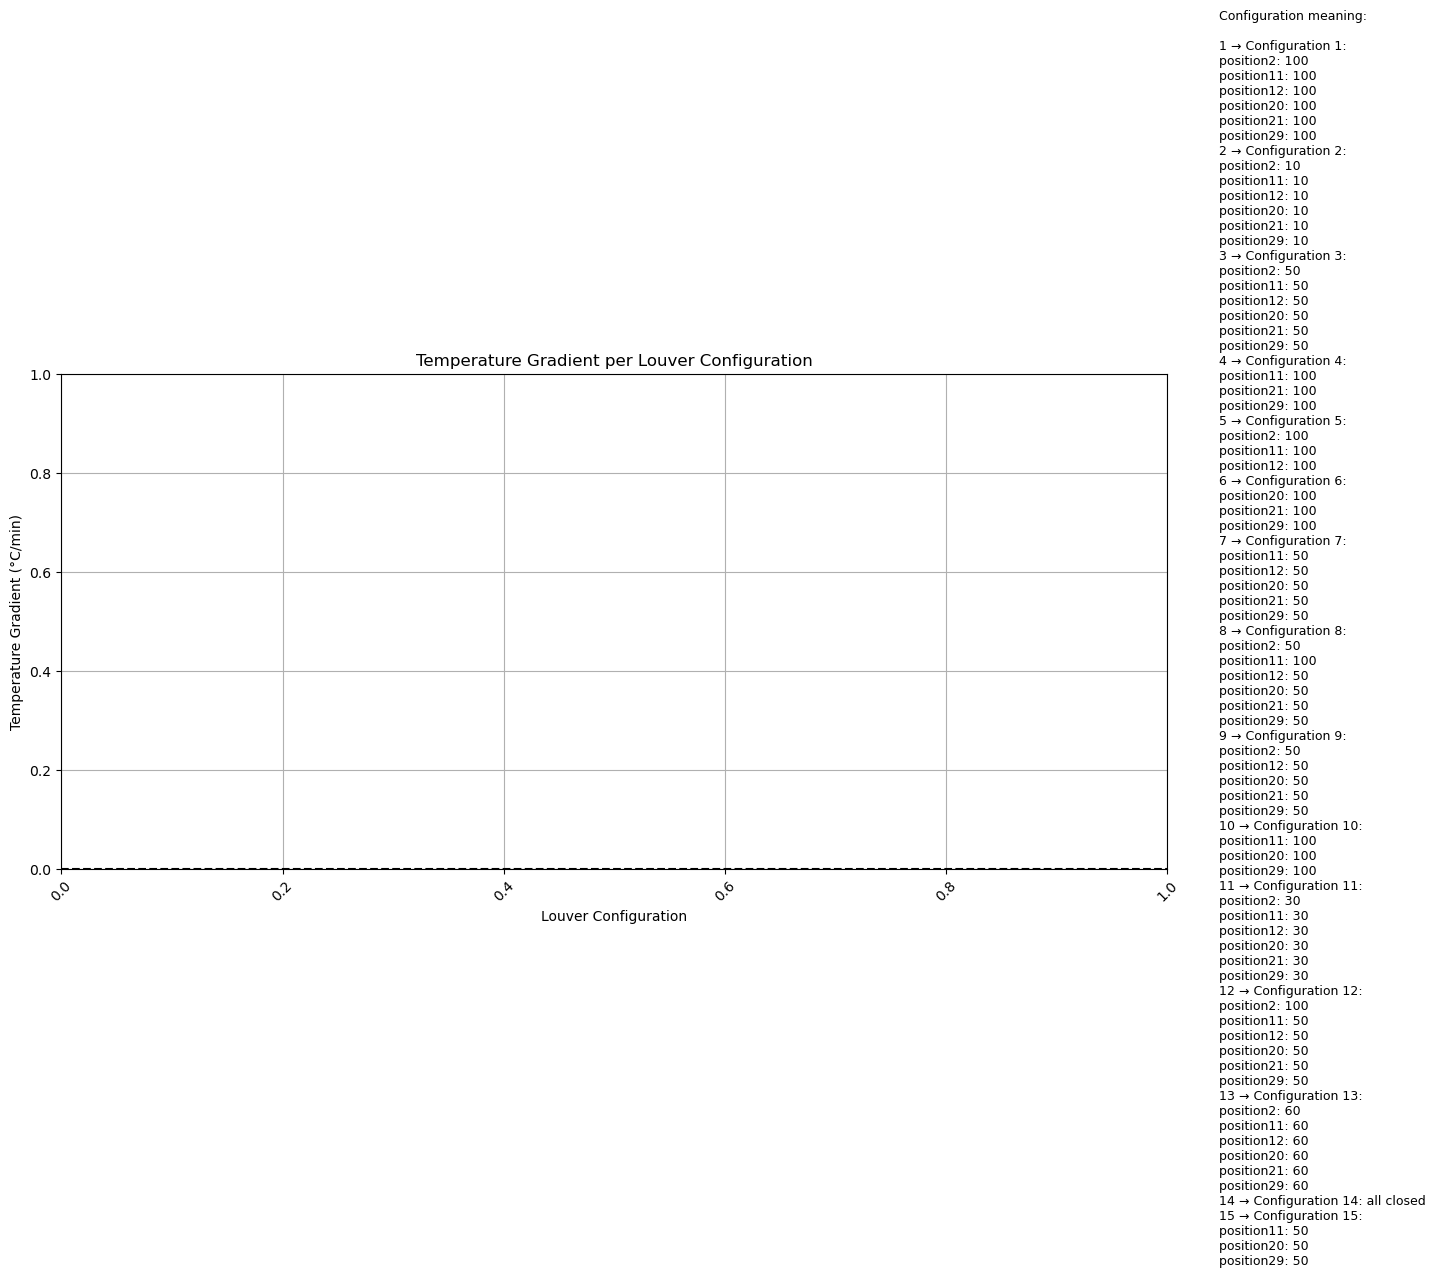

In [45]:
plot_temp_gradient_per_louver(df_stats, df_setlouvers)

## ESS Temperature:  telescope vs outside temperature difference

In [ ]:
# Keep only the ESS identities with 113 and 301
df_temp_dout_telescope = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:113','ESS:301'])
].copy()

In [ ]:
df_temp_dout_telescope.head()

### Plots of telescope sensors (113 and 301)

In [ ]:
plot_temperature(df_temp_dout_telescope, title="Temperature Telescope and Outside")

### Cross with the louver settings

In [ ]:
plot_temperature_with_line_louvers(
    df_temp_dout_telescope,
    df_setlouvers,
    "Temperature Telescope and Outside with Louver Configuration"
)

In [ ]:
# Add time to the new df
df_temp_dout_telescope['time'] = pd.to_datetime(df_temp_dout_telescope['timestamp'], unit='s')

In [ ]:
plot_temperature_with_louver_shading(
    df_temp_dout_telescope,
    df_setlouvers,
    "Temperature Telescope and Outside with Louver Configuration (colored)"
)

In [ ]:
plot_temperature_with_louvers(
    df_temp_dout_telescope, 
    df_setlouvers)

## Make window zoom for configuration beteween 40 and 90 min

In [ ]:
plot_temperature_zoom(df_temp_dout_telescope, df_setlouvers)

Table: basic statistics per configuration (average, variation)

In [ ]:
df_temp_dout_telescope['time'] = pd.to_datetime(df_temp_dout_telescope['time'], utc=True).dt.tz_convert(None)

In [ ]:
df_stats = compute_louvers_stats(df_setlouvers, df_temp_dout_telescope)
df_stats

In [ ]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [ ]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

In [ ]:
# Summary of the different configuration of louvers
df_summary = (
    df_stats
    .groupby(['louvers_conf','conf_label','sensor'])
    .agg({
        'duration_min':'mean',
        'mean_temp':'mean',
        'std_temp':'mean',
        'gradient_deg_per_min':'mean',
        'temp_range':'mean'
    })
    .reset_index()
)

In [ ]:
df_summary

In [ ]:
plot_temp_distribution_per_louver(df_stats, df_setlouvers, value_col="mean_temp")

In [ ]:
plot_temp_stability_distribution(df_stats, df_setlouvers, value_col="std_temp")

In [ ]:
plot_temp_gradient_per_louver(df_stats, df_setlouvers)

## ESS Temperature:  telescope sensors (111-113)

In [ ]:
# Keep only the ESS identities with 111, 112 and 113
df_ess = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:112','ESS:113'])
].copy()

In [ ]:
df_ess.head()

### Plots of telescope sensors (111-113)

In [ ]:
plot_temperature(df_ess, title="ESS Temperature Sensors")

### Cross with the louver settings

In [ ]:
plot_temperature_with_line_louvers(
    df_ess,
    df_setlouvers,
    "ESS Temperature Sensors with Louver Configuration"
)

In [ ]:
# Add time to the new df
df_ess['time'] = pd.to_datetime(df_ess['timestamp'], unit='s')

In [ ]:
plot_temperature_with_louver_shading(
    df_ess,
    df_setlouvers,
    "ESS Temperature Sensors with Louver Configuration (colored)"
)

In [ ]:
plot_temperature_with_louvers(
    df_ess, 
    df_setlouvers)

## Make window zoom for configuration beteween 40 and 90 min

In [ ]:
plot_temperature_zoom(df_ess, df_setlouvers)

Table: basic statistics per configuration (average, variation)

In [ ]:
df_ess['time'] = pd.to_datetime(df_ess['time'], utc=True).dt.tz_convert(None)

In [ ]:
df_stats = compute_louvers_stats(df_setlouvers, df_ess)
df_stats

In [ ]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [ ]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

In [ ]:
# Summary of the different configuration of louvers
df_summary = (
    df_stats
    .groupby(['louvers_conf','conf_label','sensor'])
    .agg({
        'duration_min':'mean',
        'mean_temp':'mean',
        'std_temp':'mean',
        'gradient_deg_per_min':'mean',
        'temp_range':'mean'
    })
    .reset_index()
)

In [ ]:
df_summary

In [ ]:
plot_temp_distribution_per_louver(df_stats, df_setlouvers, value_col="mean_temp")

In [ ]:
plot_temp_stability_distribution(df_stats, df_setlouvers, value_col="std_temp")

In [ ]:
plot_temp_gradient_per_louver(df_stats, df_setlouvers)

# Plots of windows zoom with all sensors

We're going to select the 4 sensors and generate plots only for the zoom windows corresponding to the configurations that were active between 40 and 90 minutes.

In [ ]:
# Keep only the ESS identities with 111, 112 and 113
df_allsensors = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:112','ESS:113', 'ESS:301'])
].copy()

In [ ]:
plot_temperature_zoom(df_allsensors, df_setlouvers)